In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
modul_path = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics

### Model/ Parameter Definition

In [2]:
k1 = 2.0
k2 = 0.002
k3 = 2.0
A0 = 50
B0 = 60
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2])

S = np.array([[1,-1,0],[0,1,-1]])
S_ed = np.array([[1,1,0],[0,1,1]],dtype=int)
c = np.array([k1,k2,k3]) # assuming this are already the volume dependent constants...
x0 = np.array([A0,B0])

### Deterministic

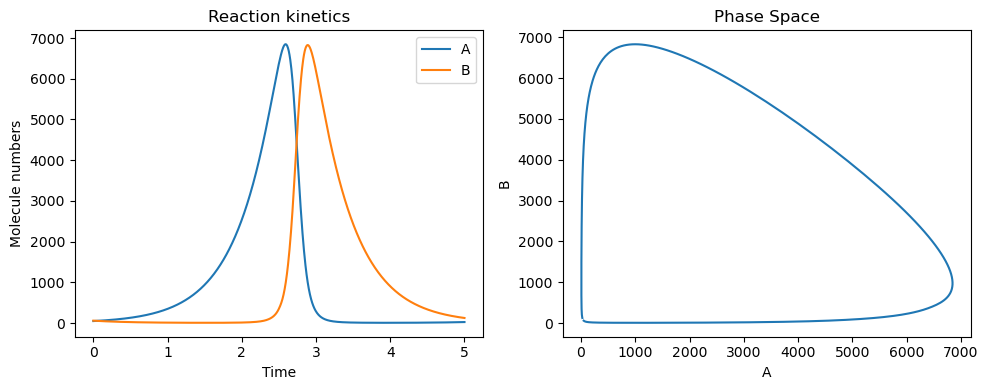

In [4]:
# Solving Lottka Volterra generally
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib import pyplot as plt

def prey_hunter(t,x,k1,k2,k3):
    x_dot = k1*x[0] - k2*x[0]*x[1]
    y_dot = k2*x[0]*x[1] - k3*x[1]
    return([x_dot,y_dot])


t_start = 0
t_end = 5
n = 1000
t_eval = np.linspace(t_start, t_end, n) 

volterra = solve_ivp(prey_hunter, (t_start,t_end), [A0,B0],method = "RK45",t_eval=t_eval, args=(k1,k2,k3))
# print(dir(volterra))

# Visualising the result
x = volterra.y[0]
y = volterra.y[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(volterra.t, volterra.y[0], label="A")
ax1.plot(volterra.t, volterra.y[1], label="B")
ax1.legend()
ax1.set_xlabel("Time")
ax1.set_ylabel("Molecule numbers")
ax1.set_title("Reaction kinetics")

# Phase Space
ax2.plot(x,y)
ax2.set_xlabel("A")
ax2.set_ylabel("B")
ax2.set_title("Phase Space")

plt.tight_layout()

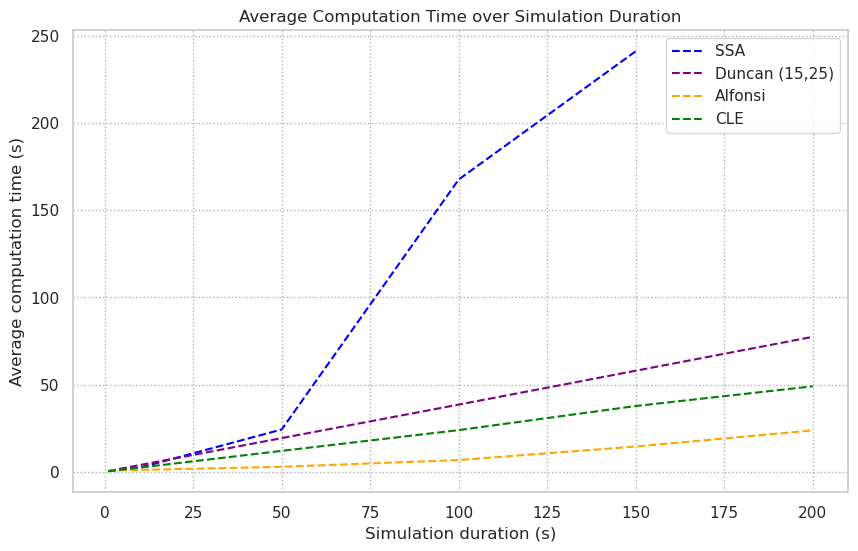

In [30]:
# Time Complexity Plot

t_range = [1,10,50,100,150,200]

CLE= [0.24980626058578492, 2.378041152715683, 11.943361939191819, 23.860449375152587 , 37.69703698945045,49.001947798252104]
Hybrid_Duncan = [0.3794647858142853, 3.8290441079139708, 19.26873395228386, 38.50131588602066, 57.937969374656674, 77.40260093307495]
alfonsi = [0.6923761098384857,1.0159748141765594, 2.8079019129276275, 6.675473123311996, 14.443160779714585, 23.695532138109208]
SSA =[0.335741,2.352200,24.220348,167.701863,241.29655367126085,271.0882309050409]




fig,ax = plt.subplots(figsize=(10,6))
ax.plot(t_range[:-1],SSA[:-1],color="blue", ls="--",label="SSA")
ax.plot(t_range,Hybrid_Duncan,color="purple", ls="--",label="Duncan (15,25)")
ax.plot(t_range,alfonsi,color="orange", ls="--",label="Alfonsi")
ax.plot(t_range,CLE,color="green", ls="--",label="CLE")
#ax.set_yscale('log')
#ax.set_ylim(10**(-5), 10**1)
ax.set_xlabel("Simulation duration (s)")
ax.set_ylabel("Average computation time (s)")
ax.legend()
ax.set_title("Average Computation Time over Simulation Duration")
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/Final_report/Images/computation_time_comparison_bacteriophage.png")
plt.show()

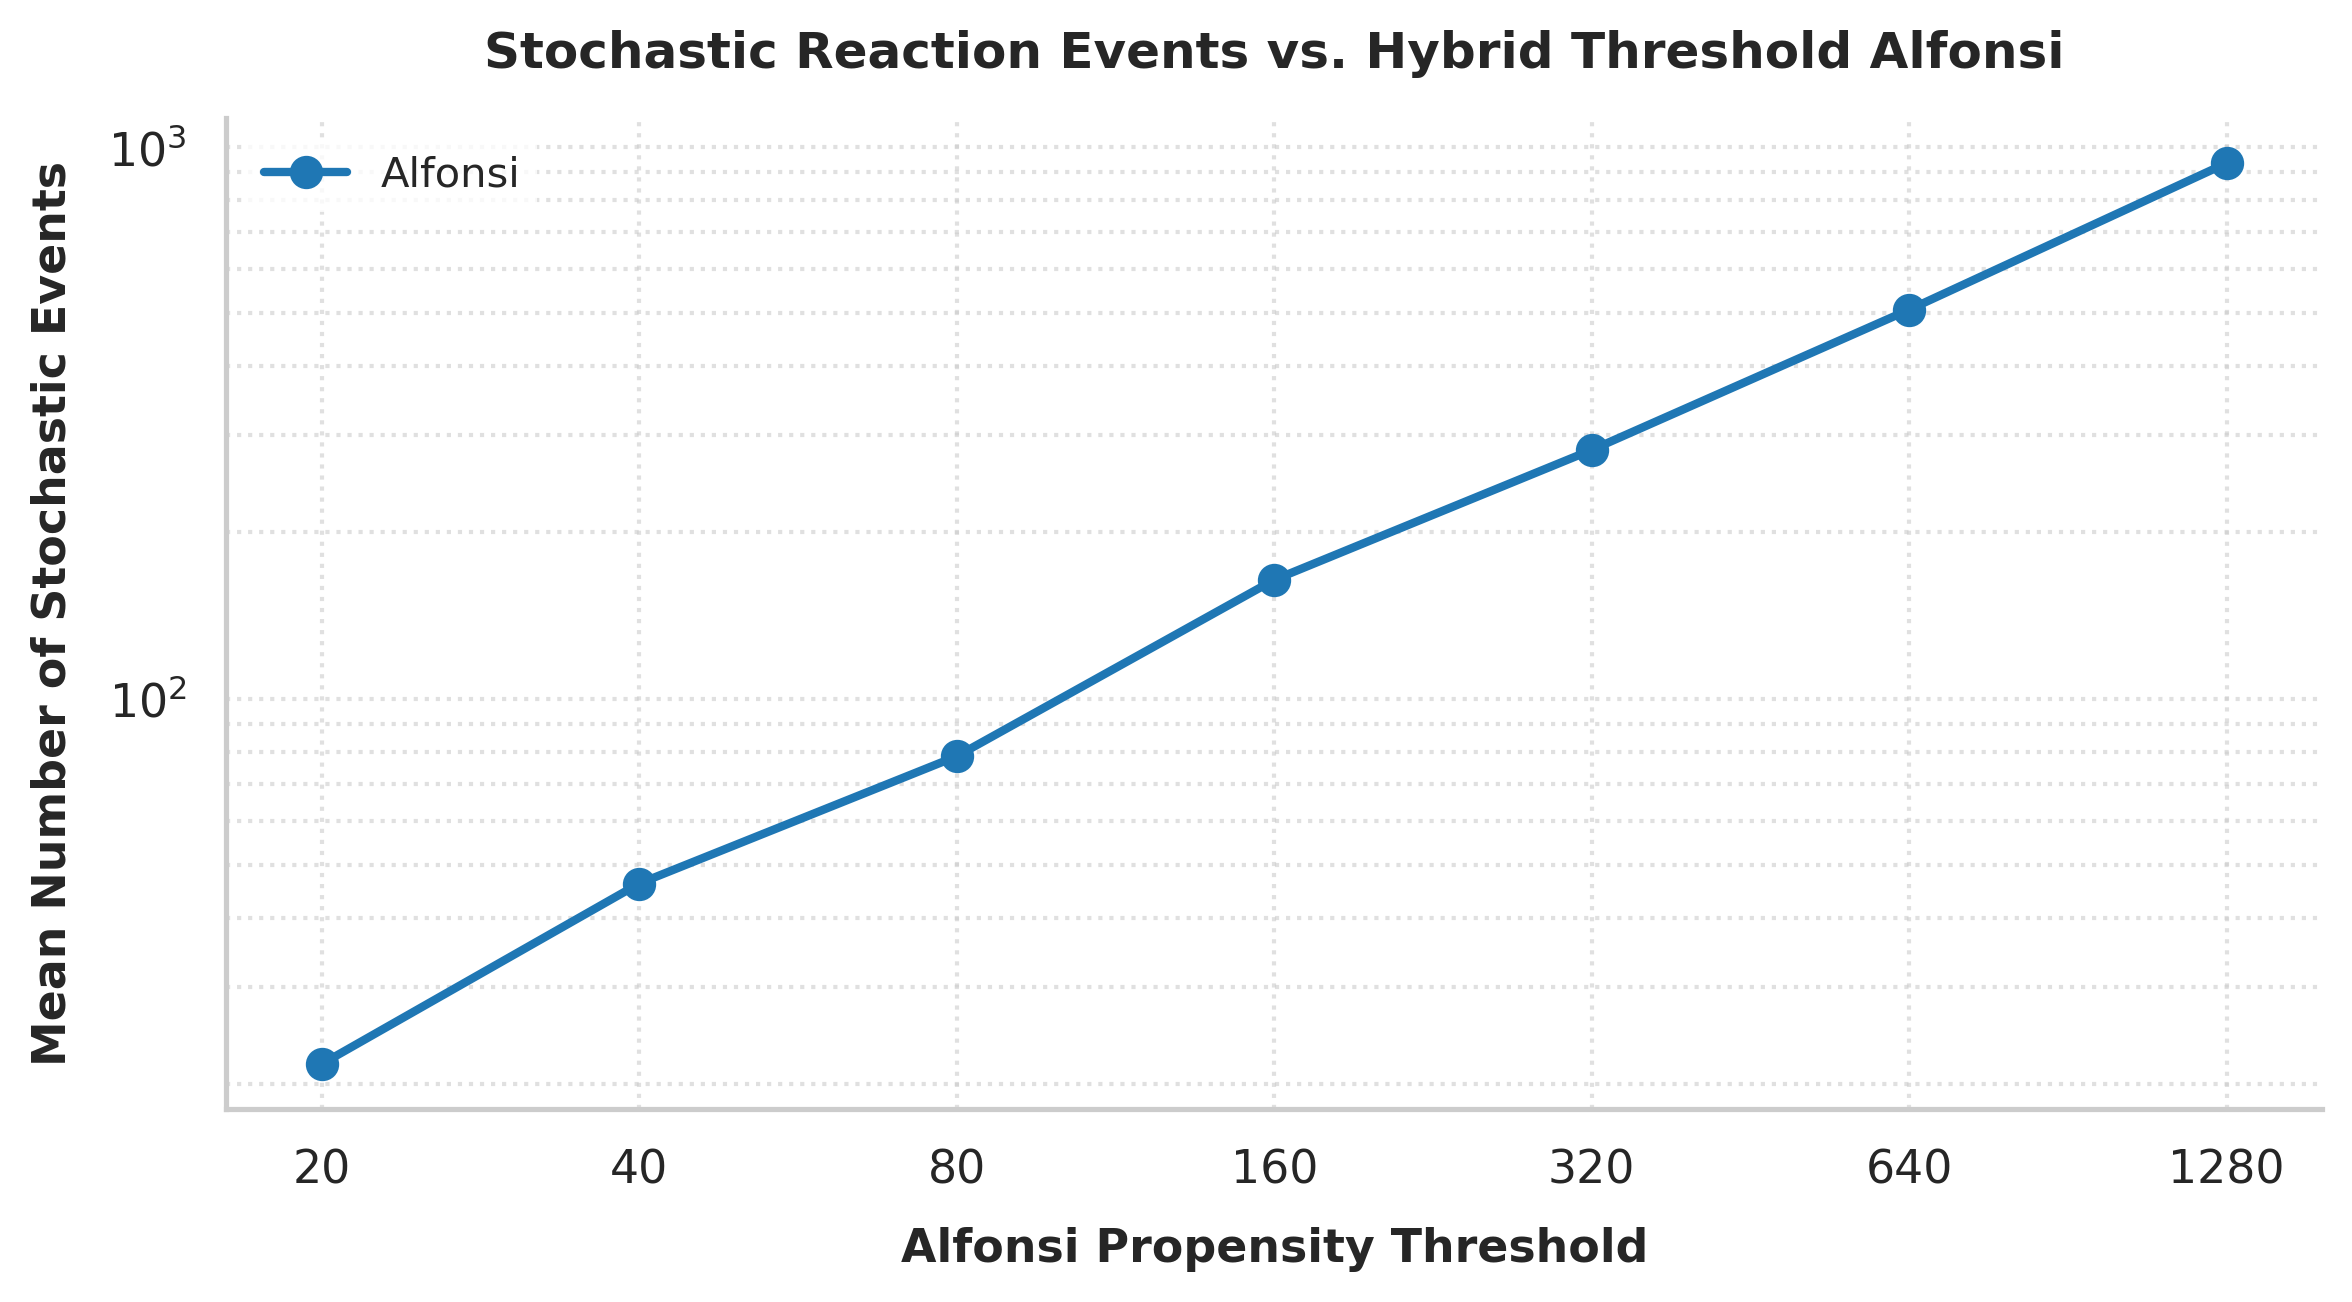

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daten
N_alfonsi = [ 21.737,46.185,78.567,164.125,282.349,507.135,935.262]
parameter_values = [20, 40, 80, 160, 320, 640,1280]

# Stil & Layout vorbereiten
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

# Farben definieren
color_alfonsi = "#1f77b4"  # Blau
color_duncan = "#d62728"   # Rot

# Daten plotten (mit Linien und Markern)
ax.plot(parameter_values, N_alfonsi, marker='o', linewidth=2, markersize=7, 
        label="Alfonsi", color=color_alfonsi)

# Achseneinstellungen & Skalierung
ax.set_yscale("log")  # Log-Skala, da Duncan & Alfonsi stark abweichen
ax.set_xscale("log", base=2)  # Log2-Skala passt perfekt zur Verdopplung der Parameter
ax.set_xticks(parameter_values)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Labels & Titel
ax.set_xlabel("Alfonsi Propensity Threshold", fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel("Mean Number of Stochastic Events", fontsize=11, fontweight='bold', labelpad=8)
ax.set_title("Stochastic Reaction Events vs. Hybrid Threshold Alfonsi", fontsize=12, fontweight='bold', pad=12)

# Details (Legende, Spines, Grid)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='best')
ax.grid(True, which="both", linestyle=":", alpha=0.6)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig("/home/jona/Schreibtisch/Project_Work_report_Claude/Images/events_per_parameter_alfonsi.png")
plt.show()

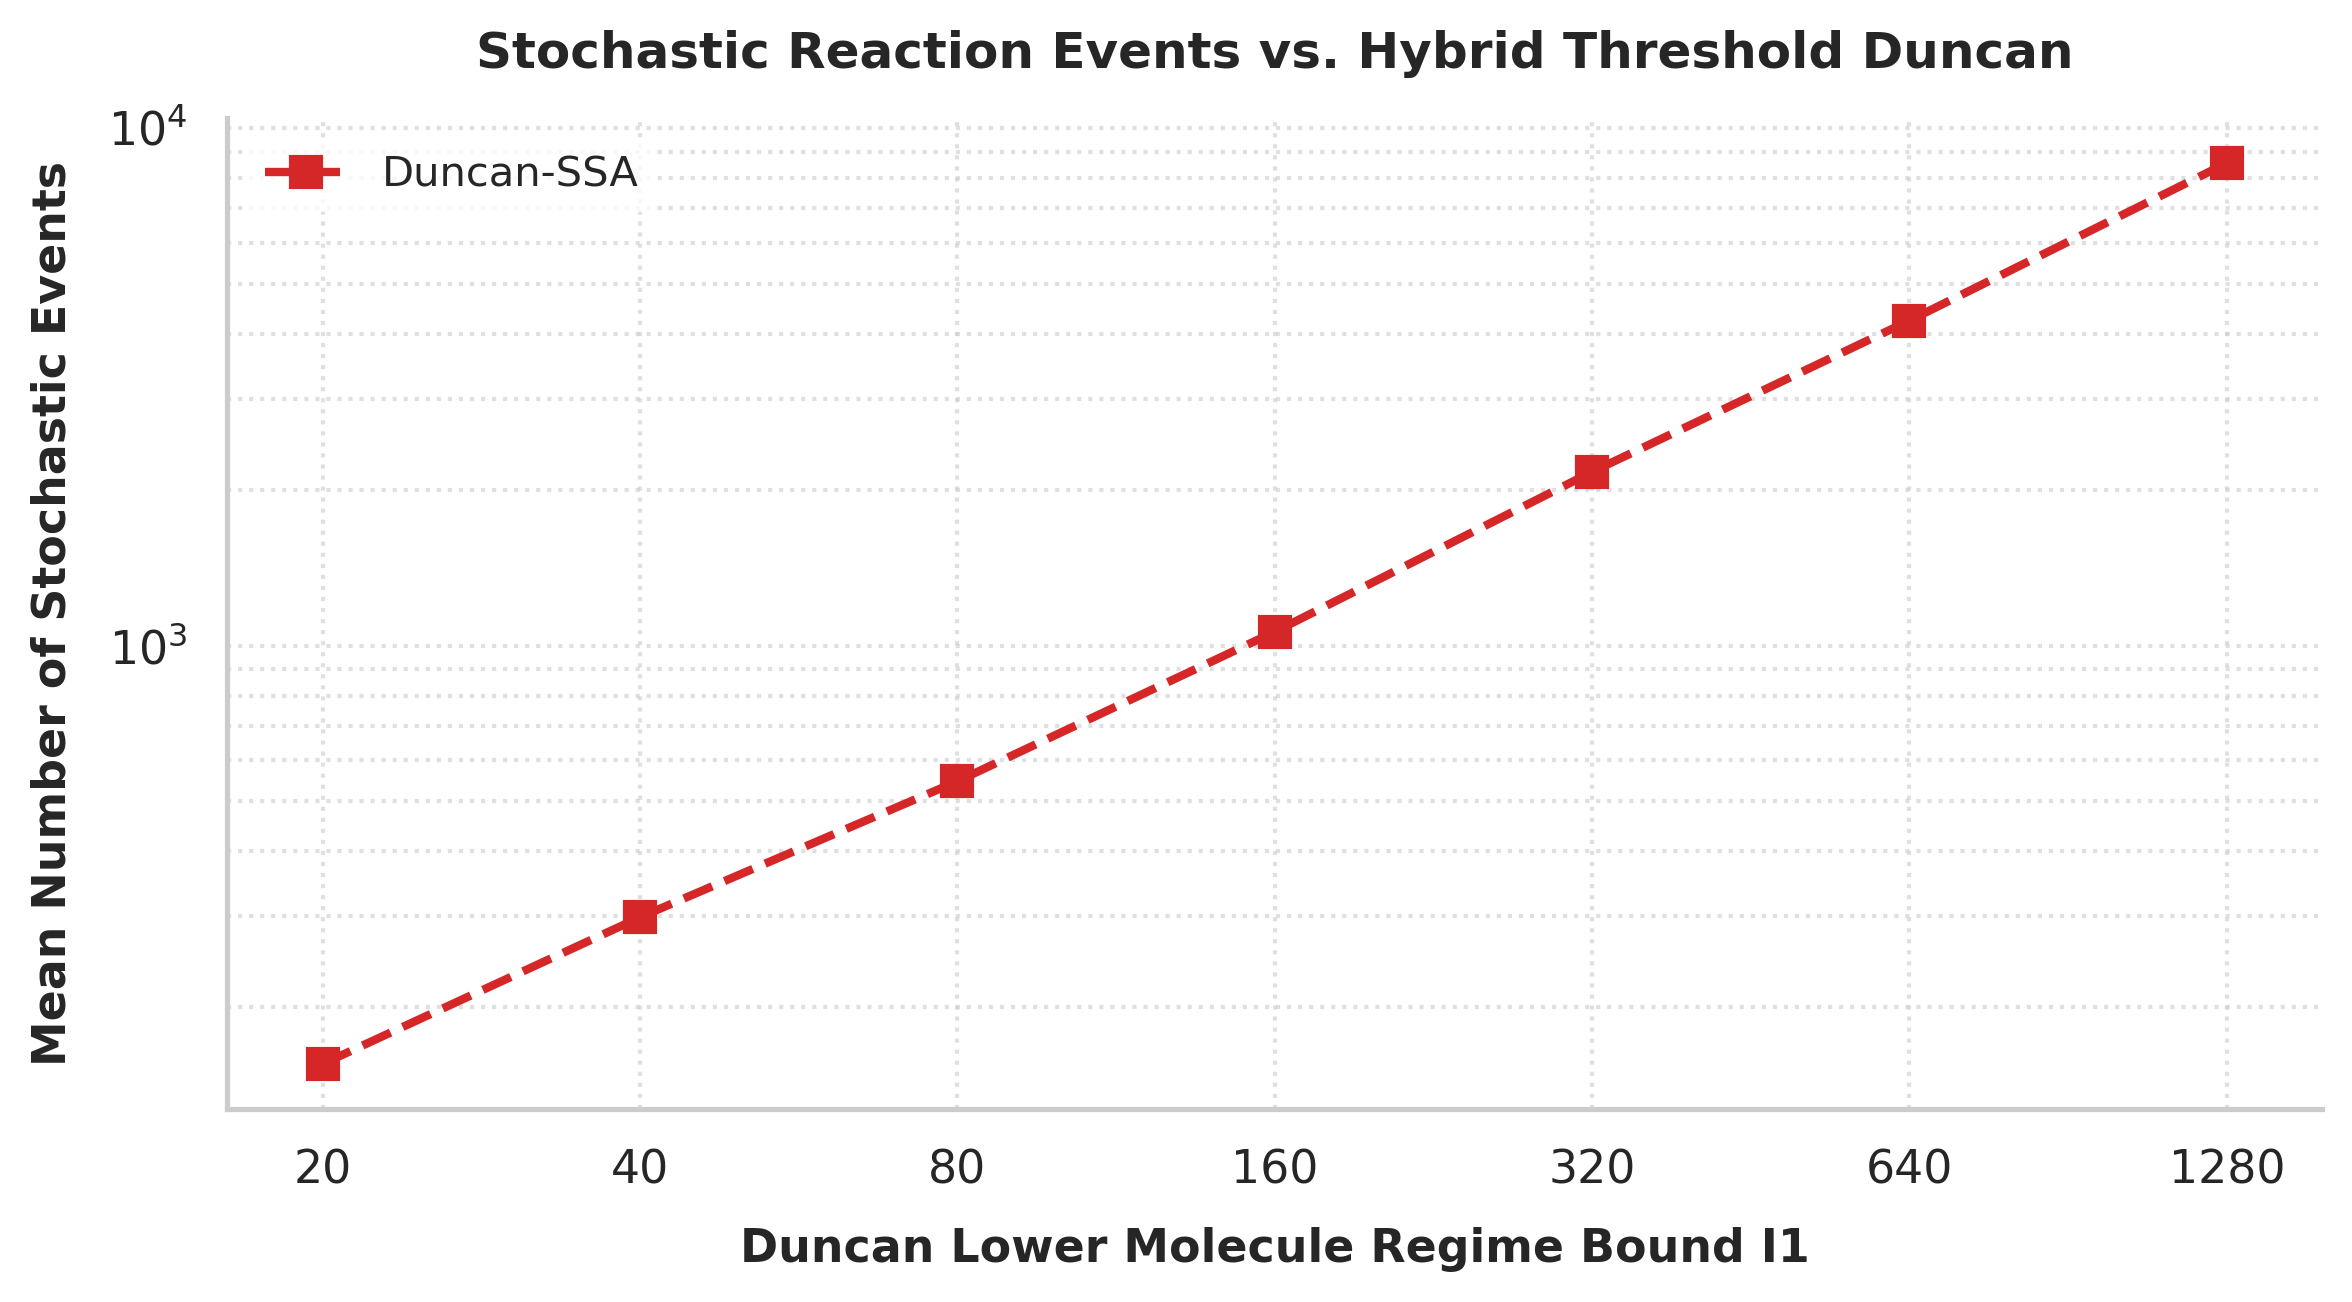

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daten
N_duncan = [ 155.164,298.161,546.247,1062.741, 2166.289, 4248.304, 8566.649]

parameter_values = [20, 40, 80, 160, 320, 640,1280]


# Stil & Layout vorbereiten
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

# Farben definieren
color_alfonsi = "#1f77b4"  # Blau
color_duncan = "#d62728"   # Rot

# Daten plotten (mit Linien und Markern)
ax.plot(parameter_values, N_duncan, marker='s', linewidth=2, markersize=7, 
        linestyle='--', label="Duncan-SSA", color=color_duncan)

# Achseneinstellungen & Skalierung
ax.set_yscale("log")  # Log-Skala, da Duncan & Alfonsi stark abweichen
ax.set_xscale("log", base=2)  # Log2-Skala passt perfekt zur Verdopplung der Parameter
ax.set_xticks(parameter_values)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Labels & Titel
ax.set_xlabel("Duncan Lower Molecule Regime Bound I1", fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel("Mean Number of Stochastic Events", fontsize=11, fontweight='bold', labelpad=8)
ax.set_title("Stochastic Reaction Events vs. Hybrid Threshold Duncan", fontsize=12, fontweight='bold', pad=12)

# Details (Legende, Spines, Grid)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='best')
ax.grid(True, which="both", linestyle=":", alpha=0.6)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig("/home/jona/Schreibtisch/Project_Work_report_Claude/Images/events_per_parameter_duncan.png")
plt.show()

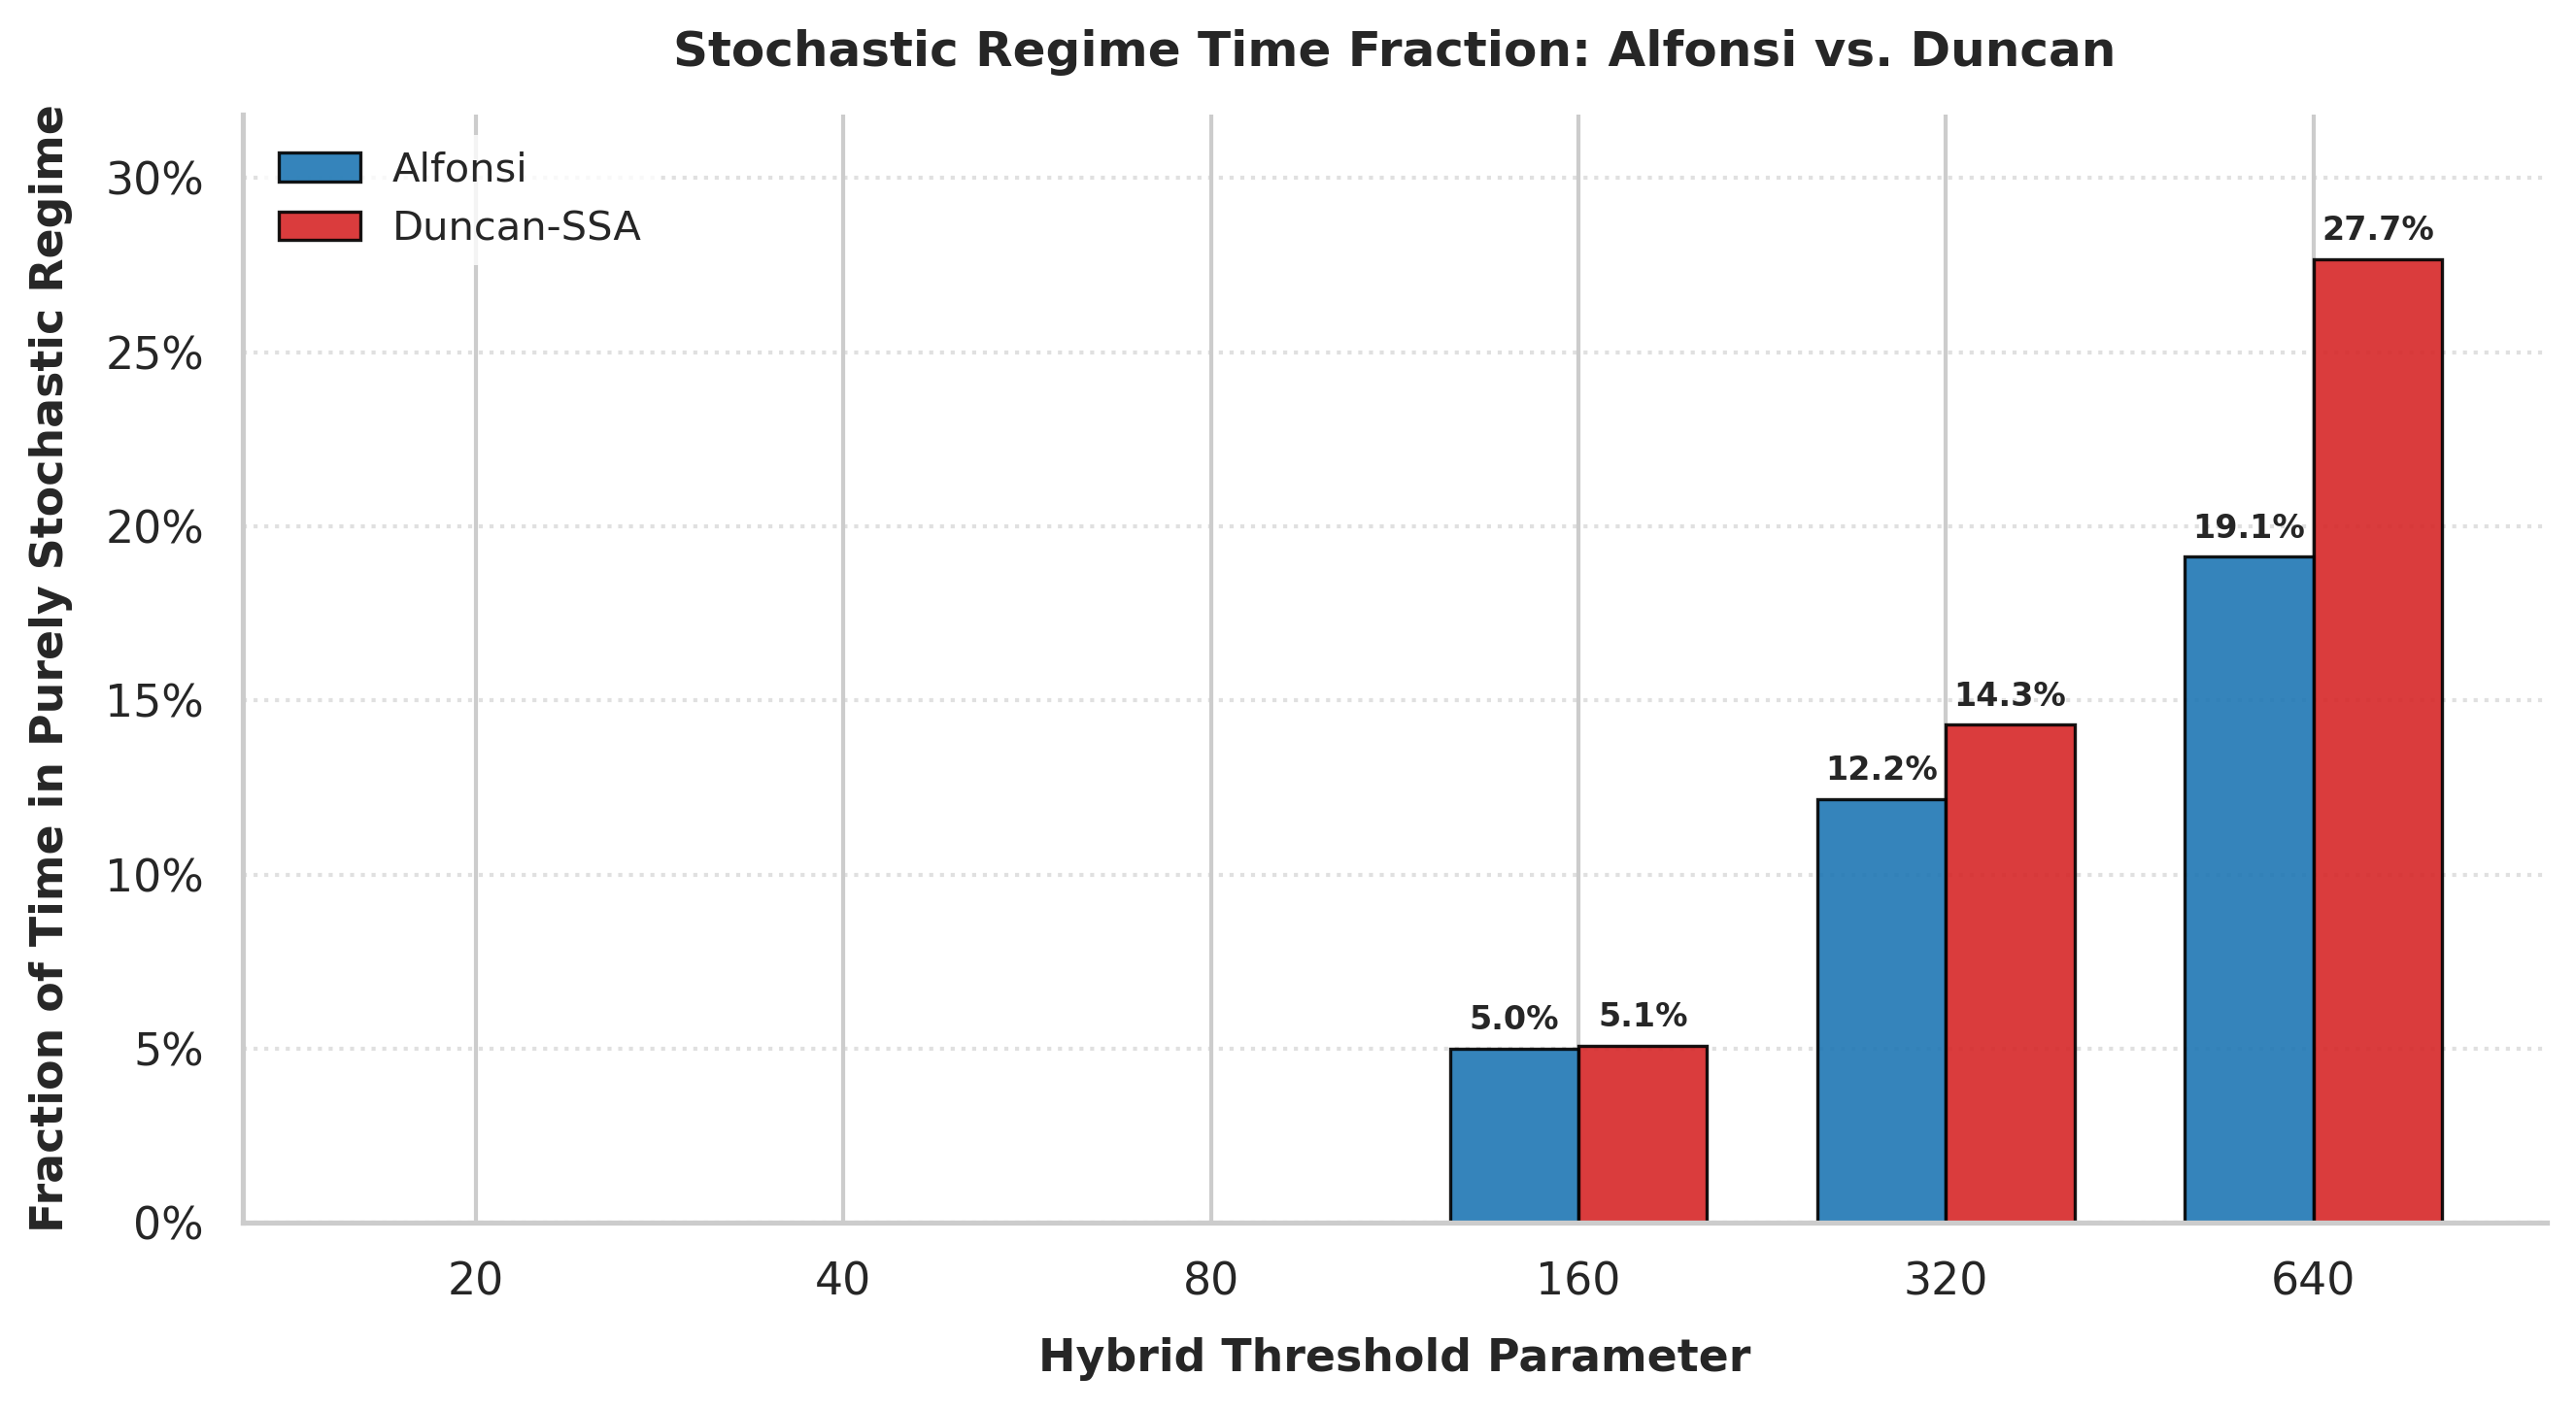

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Daten
parameter_values = [20, 40, 80, 160, 320, 640]
alfonsi_Zeitanteile = np.array([0, 0, 0, 0.2501621, 0.60849451, 0.95615308]) / 5
duncan_Zeitanteile = np.array([0, 0, 0, 0.25397613, 0.71528997, 1.38376588]) / 5

# Layout-Einstellungen
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

x = np.arange(len(parameter_values))
width = 0.35  # Breite der Einzelbalken

# Balken plotten
rects1 = ax.bar(x - width/2, alfonsi_Zeitanteile, width, label='Alfonsi', 
               color='#1f77b4', edgecolor='black', linewidth=0.8, alpha=0.9)
rects2 = ax.bar(x + width/2, duncan_Zeitanteile, width, label='Duncan-SSA', 
               color='#d62728', edgecolor='black', linewidth=0.8, alpha=0.9)

# Achsenbeschriftung und Formatisierung
ax.set_xlabel("Hybrid Threshold Parameter", fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel("Fraction of Time in Purely Stochastic Regime", fontsize=11, fontweight='bold', labelpad=8)
ax.set_title("Stochastic Regime Time Fraction: Alfonsi vs. Duncan", fontsize=12, fontweight='bold', pad=12)

ax.set_xticks(x)
ax.set_xticklabels(parameter_values)
ax.set_ylim(0, max(max(alfonsi_Zeitanteile), max(duncan_Zeitanteile)) * 1.15)

# Y-Achse als Prozentwerte formatieren (0% bis 100%)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Werte oben auf den Balken einblenden (nur wenn > 0)
for rect in rects1 + rects2:
    height = rect.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.1%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Points Versatz nach oben
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper left')
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
sns.despine(top=True, right=True)
plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/Final_report/Images/fraction_stochastic_regime.png")
plt.tight_layout()
plt.show()

In [5]:
print(x.min(),x.max())
print(y.min(),y.max())

7.475352426031922 6846.564671049905
7.374008183692565 6826.642733226108


### CLE

100%|██████████| 1000/1000 [00:04<00:00, 220.94it/s]


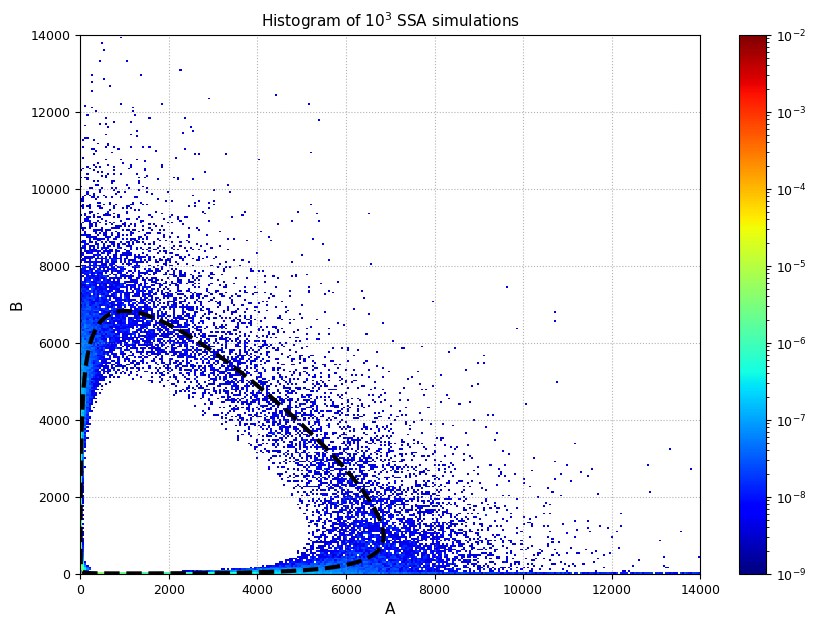

In [33]:
from tqdm import tqdm
import matplotlib.colors as colors
t0 = 0
tf = 5
n = 1000
Delta_t = 4*10**(-2)
result_cle = []


for i in tqdm(range(n)):
    t,z = stochastinetics.cle_trajectory(S,S_ed,c,t0,x0,tf,Delta_t)
    result_cle.append([t,z[:,0],z[:,1]])
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_cle_dezi_centi_second4.csv")
stochastinetics.save_sim_results(result_cle,path)  

all_A = np.concatenate([traj[1] for traj in result_cle])
all_B = np.concatenate([traj[2] for traj in result_cle])

fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)
fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3)
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_title('Histogram of $10^3$ SSA simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
plt.show()

### Reflective vs. Absorbing Boundary Condition

1000 simulation runs have been reconstructed succesfully.
1000 simulation runs have been reconstructed succesfully.
1000 simulation runs have been reconstructed succesfully.


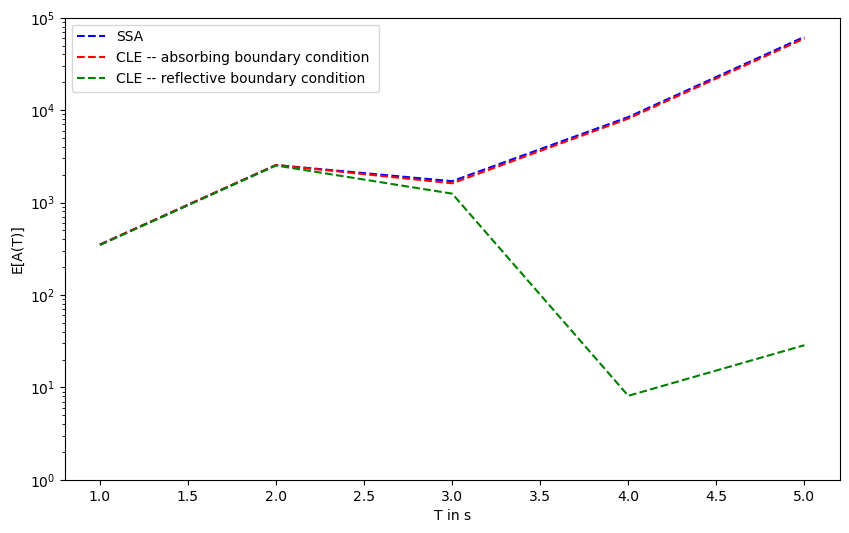

In [27]:
# Expectation Value over Time --> run cle-simulation in advance!

folder = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
result_cle_reflective = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_cle_milisecond.csv"),3)
result_ssa = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_ssa.csv"),3)
result_cle_absorbing = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_cle_milisecond2.csv"),3)

t_range = np.arange(1,6)

ssa_exp = stochastinetics.expectation(result_ssa,n,t_range)
cle_exp_reflective = stochastinetics.expectation(result_cle_reflective,n,t_range)
cle_exp_absorbing = stochastinetics.expectation(result_cle_absorbing,n,t_range)

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(t_range,ssa_exp[:,0],color="blue", ls="--",label="SSA")
ax.plot(t_range,cle_exp_absorbing[:,0],color="red", ls="--",label="CLE -- absorbing boundary condition ")
ax.plot(t_range,cle_exp_reflective[:,0],color="green", ls="--",label="CLE -- reflective boundary condition")
ax.set_ylabel(r"E[A(T)]")
ax.set_xlabel("T in s")
ax.set_yscale('log')
ax.set_ylim(1, 100000)
ax.legend()
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_reflective_vs_absorbing_boundary_condition2.png")
plt.savefig(path)
plt.show()

### Step Size CLE-Accuracy based

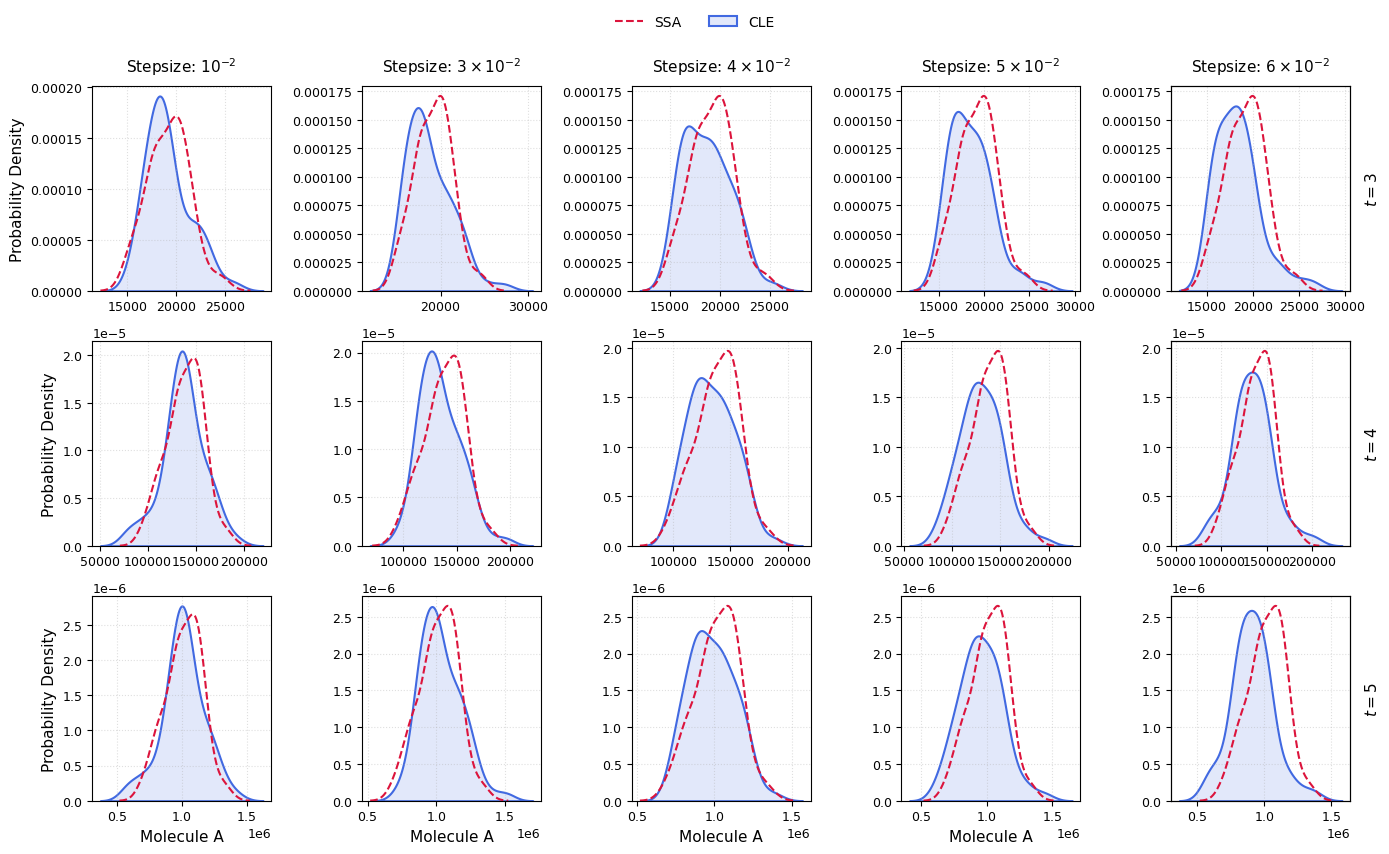

MannwhitneyuResult(statistic=np.float64(509135.5), pvalue=np.float64(0.4779070049525903))
MannwhitneyuResult(statistic=np.float64(513478.5), pvalue=np.float64(0.2949133147997206))
MannwhitneyuResult(statistic=np.float64(492209.5), pvalue=np.float64(0.5453083448544642))
MannwhitneyuResult(statistic=np.float64(478516.5), pvalue=np.float64(0.09543247081281163))
MannwhitneyuResult(statistic=np.float64(462745.0), pvalue=np.float64(0.0038553908574654465))


In [ ]:
# probability dist für verschiedene Step Sizes

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    i = 0
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[i,2*j:2*j+2] = current_result[1][idx].copy()
        i+=1
    return data

path_ssa= "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_ssa.csv"
path_cle5 = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_cle_dezi_centi_second5.csv"
path_cle3 = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_cle_dezi_centi_second3.csv"
path_cle4 = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_cle_dezi_centi_second4.csv"
path_cle6 = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_cle_dezi_centi_second6.csv"
path_cle = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_cle_centisecond2.csv"

time_points = np.linspace(1,5,1000)

data_cle5 = np.zeros((1000,2*len(time_points)))
data_cle4 = np.zeros((1000,2*len(time_points)))
data_cle3 = np.zeros((1000,2*len(time_points)))
data_cle6 = np.zeros((1000,2*len(time_points)))
data_cle = np.zeros((1000,2*len(time_points)))
data_ssa = np.zeros((1000,2*len(time_points)))


print("Starte mit SSA")
data_ssa = fill_time_dict_gen(data_ssa, path_ssa,3,1000,time_points)

print("Starte mit CLE5")
data_cle5 = fill_time_dict_gen(data_cle5,path_cle5,3,1000,time_points)
print("Starte mit CLE3")
data_cle3 = fill_time_dict_gen(data_cle3,path_cle3,3,1000,time_points)
print("Starte mit CLE4")
data_cle4 = fill_time_dict_gen(data_cle4,path_cle4,3,1000,time_points)
print("Starte mit CLE6")
data_cle6 = fill_time_dict_gen(data_cle6,path_cle6,3,1000,time_points)
data_cle = fill_time_dict_gen(data_cle,path_cle,3,1000,time_points)


data_ssa2 = data_ssa[:,np.array([True if i%2==0 else False for i in range(data_ssa.shape[1])])]
data_cle5 = data_cle5[:,np.array([True if i%2==0 else False for i in range(data_cle5.shape[1])])]
data_cle3 = data_cle3[:,np.array([True if i%2==0 else False for i in range(data_cle3.shape[1])])]
data_cle6 = data_cle6[:,np.array([True if i%2==0 else False for i in range(data_cle6.shape[1])])]
data_cle = data_cle[:,np.array([True if i%2==0 else False for i in range(data_cle.shape[1])])]
data_cle4 = data_cle4[:,np.array([True if i%2==0 else False for i in range(data_cle4.shape[1])])]


plt.rcParams.update({'font.size': 10,'axes.labelsize': 11,'axes.titlesize': 11,'xtick.labelsize': 9,'ytick.labelsize': 9,'grid.alpha': 0.4,'grid.linestyle': ':'})

t_plot = [3, 4, 5]
indices = [np.searchsorted(time_points, i) for i in t_plot]
n_rows = len(t_plot)

stepsizes = [r"$10^{-2}$", r"$3 \times 10^{-2}$",r"$4 \times 10^{-2}$", r"$5 \times 10^{-2}$", r"$6 \times 10^{-2}$"]
cle_datasets = [data_cle, data_cle3,data_cle4, data_cle5, data_cle6]
cle_currs = []

fig, axes = plt.subplots(nrows=n_rows, ncols=5, figsize=(14, 2.8 * n_rows), sharex=False, sharey=False)

for j, idx in enumerate(indices):
    data_ssa3 = data_ssa2[:, idx]
    data_ssa4 = data_ssa3[data_ssa3 >= 15000]

    for k, data_cle_raw in enumerate(cle_datasets):
        ax = axes[j, k]
        
        data_cle_curr = data_cle_raw[:, idx]
        data_cle_curr2 = data_cle_curr[data_cle_curr >= 15000]
        
        if j == len(t_plot)-1:
            cle_currs.append(data_cle_curr)


        sns.kdeplot(data_ssa4, ax=ax, color="crimson", linestyle="--", label="SSA", linewidth=1.5)
        sns.kdeplot(np.round(data_cle_curr2), ax=ax, color="royalblue", label="CLE", linewidth=1.5, fill=True, alpha=0.15)

        ax.grid(True)
        ax.set_ylabel("")
        ax.set_xlabel("")

        if k == 4:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"$t = {t_plot[j]}$", fontsize=11, labelpad=10)
            ax2.set_yticks([])

for k, step_str in enumerate(stepsizes):
    axes[0, k].set_title(f"Stepsize: {step_str}", pad=10)

for row_idx in range(n_rows):
    axes[row_idx, 0].set_ylabel("Probability Density")

for col_idx in range(4):
    axes[-1, col_idx].set_xlabel("Molecule A")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)

plt.tight_layout()
fig.subplots_adjust(top=0.92)

#plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/step_size_comparison_prob_dist.png", dpi=300, bbox_inches="tight")
plt.show()

print(stats.mannwhitneyu(data_ssa3,cle_currs[0]))
print(stats.mannwhitneyu(data_ssa3,cle_currs[1]))
print(stats.mannwhitneyu(data_ssa3,cle_currs[2]))
print(stats.mannwhitneyu(data_ssa3,cle_currs[3]))
print(stats.mannwhitneyu(data_ssa3,cle_currs[4]))

### Step-Size CLE Propensity based

In [ ]:
%load_ext autoreload
%autoreload 2
from tqdm import tqdm
import scipy
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
modul_path = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics

def CLE_diff_SSA(x0,delta_t,n,S,S_ed,c,reaction):
    alpha_cle = []
    alpha_ssa = []
    for i in range(n):
        x_t_ssa = stochastinetics.SSA(S,S_ed,c,0,x0,delta_t)[1]
        x_t_cle = stochastinetics.cle(x0,c,delta_t,S,S_ed)
        alpha_cle.append(stochastinetics.propensity(reaction,x_t_cle,c,S_ed))
        alpha_ssa.append(stochastinetics.propensity(reaction,x_t_ssa,c,S_ed))
    if np.std(alpha_ssa) == 0:
        return 0
    else:    
        D = (np.mean(alpha_cle)-np.mean(alpha_ssa))
    return D

M = 10
n = 10
k1 = 2.0
k2 = 0.002
k3 = 2.0
A0 = 50
B0 = 60
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2])

S = np.array([[1,-1,0],[0,1,-1]])
S_ed = np.array([[1,1,0],[0,1,1]],dtype=int)
c = np.array([k1,k2,k3]) 
x0 = np.array([A0,B0])

space = np.arange(0,12000)
A_rand = np.random.choice(space,M)
B_rand = np.random.choice(space,M)

t_range = [10**(-6),10**(-3),10**(-2),3*10**(-2),5*10**(-2),7*10**(-2),10**(-1)]
for delta_t in t_range:
    for reaction in range(S.shape[1]):
        print(f"reaction: {reaction}")
        D = []
        for i in tqdm(range(M)):
            D.append(CLE_diff_SSA(np.array([A_rand[i],B_rand[i]]),delta_t,n,S,S_ed,c,reaction))
        res = scipy.stats.wilcoxon(D)
        print(f"Delta_t: {delta_t},  Wilcoxon-Rank-Test: {res.statistic}, {res.pvalue}")

reaction: 0


  0%|          | 0/1000 [00:00<?, ?it/s]

 33%|███▎      | 330/1000 [17:26<35:24,  3.17s/it]  


KeyboardInterrupt: 

In [5]:
import numpy as np
import csv
import sys

def is_oscillatory(X, extinction_species=1, eps=0):
    """
    Prueft, ob Spezies `extinction_species` (hier B, Index 1) waehrend der
    Trajektorie ausstirbt. Sobald B<=eps, ist der Zustand absorbierend
    und die Dynamik wird reines exponentielles Wachstum von A ->
    Trajektorie wird verworfen.
    """
    return not np.any(X[:, extinction_species] <= eps)


def filter_trajectories(input_path, output_path, extinction_species=1, eps=0):
    n_total = 0
    n_kept = 0
    header_written = False

    with open(output_path, "w", newline="") as f_out:
        writer = csv.writer(f_out)
        for traj_id, (t, X) in enumerate(stochastinetics.read_in_sim_results_gen(input_path,3)):
            n_total += 1
            t = np.asarray(t)
            X = np.asarray(X)

            if not is_oscillatory(X, extinction_species=extinction_species, eps=eps):
                continue
            n_kept += 1

            n_species = X.shape[1]
            if not header_written:
                writer.writerow(["traj_id", "t"] + [f"species_{i}" for i in range(n_species)])
                header_written = True

            # Falls t einen Zeitpunkt mehr enthaelt als X (T_end als Abschluss-
            # marker): letzte Zeile bekommt den letzten Zustand als Platzhalter,
            # dient im Hauptskript nur zur Bestimmung der letzten Verweildauer.
            for i in range(len(t)):
                state = X[i] if i < len(X) else X[-1]
                writer.writerow([traj_id, t[i]] + list(state))

    print(f"{n_kept}/{n_total} Trajektorien als oszillierend behalten -> {output_path}", flush=True)


if __name__ == "__main__":
    INPUT_CSV = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_ssa.csv"       
    OUTPUT_CSV = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_ssa_filtered.csv"  
    EXTINCTION_SPECIES = 1  

    filter_trajectories(INPUT_CSV, OUTPUT_CSV, extinction_species=EXTINCTION_SPECIES)

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

### SSA Algorithm

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [28:12<00:00,  1.69s/it]


Time elapsed: 1692.79851436615 seconds.


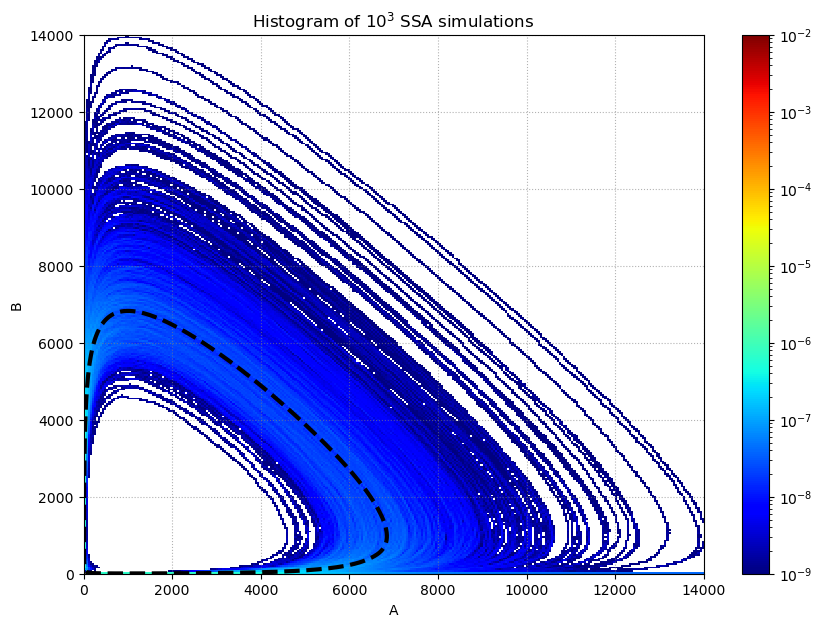

In [ ]:
from tqdm import tqdm
import time
import matplotlib.colors as colors
#ca. 28 Minuten...

t0 = 0
tf = 5
n = 1000
result_ssa = []

start = time.time()

for i in tqdm(range(n)):
    t,z = stochastinetics.SSA(S,S_ed,c,t0,x0,tf)
    result_ssa.append([t,z[:,0],z[:,1]])

end = time.time()    
all_A = np.concatenate([traj[1] for traj in result_ssa])
all_B = np.concatenate([traj[2] for traj in result_ssa])

print(f"Time elapsed: {end-start} seconds.")
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)
fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3)
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_title('Histogram of $10^3$ SSA simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
plt.show()

### Hybrid-Duncan-SSA

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:47<00:00,  9.28it/s]


NameError: name 'x' is not defined

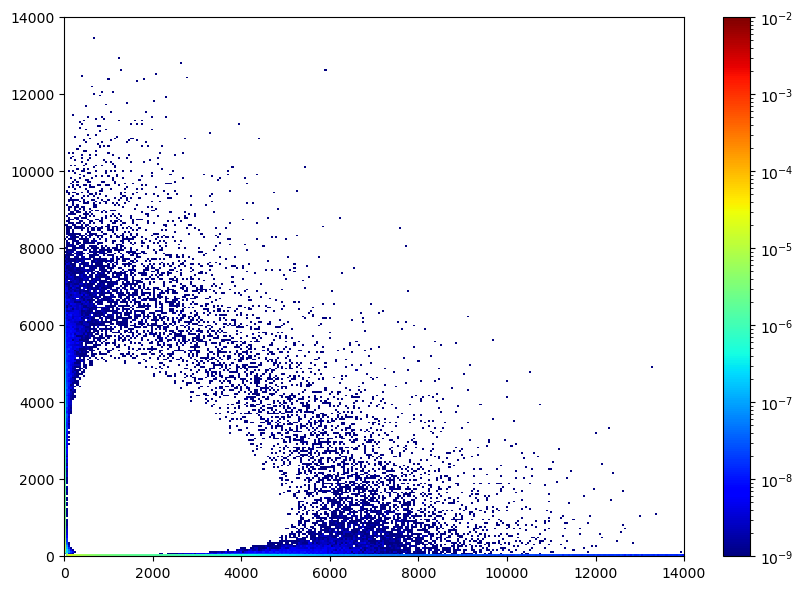

In [6]:
# Simulation Hybrid-Duncan auf Lotka-Volterra + Trajectorie Distribution
import matplotlib.colors as colors
from tqdm import tqdm
import matplotlib.pyplot as plt

t0 = 0
tf = 5
n = 1000
boundaries = np.array([25.0,35.0,25.0,35.0])
k1 = 2.0
k2 = 0.002
k3 = 2.0
A0 = 50
B0 = 60
Delta_t = 5*10**(-3)
delta_t = 5*10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2])
S = np.array([[1,-1,0],[0,1,-1]])
S_ed = np.array([[1,1,0],[0,1,1]],dtype=int)
c = np.array([k1,k2,k3])
x0 = np.array([A0,B0])
boundaries = np.array([25.0,35.0,25.0,35.0])
result_duncan = []

for i in tqdm(range(n)):
    result = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,tf,delta_t,Delta_t,boundaries)
    result_duncan.append(result)
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_duncan_ssa_stepsize_5_10_3.csv")
stochastinetics.save_sim_results(result_duncan,path)
   
all_A = np.concatenate([traj[1][:,0] for traj in result_duncan])
all_B = np.concatenate([traj[1][:,1] for traj in result_duncan])
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)

fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3)
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_title('Histogram of $10^3$ Hybrid-Duncan-SSA simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
#path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_duncan_{boundaries[0]}_{boundaries[1]}.png")
#plt.savefig(path)
#plt.show()

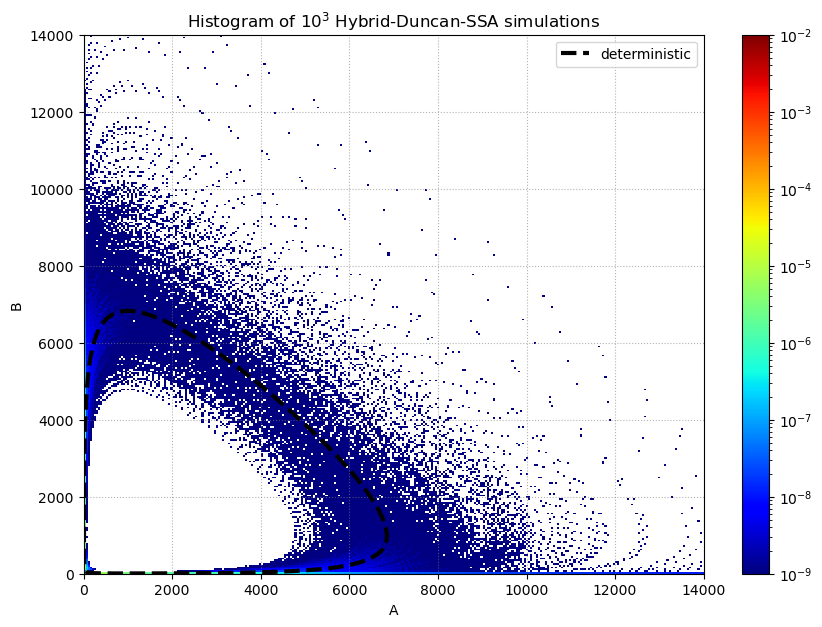

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)
fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3,label="deterministic")
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.legend()
ax.set_title('Histogram of $10^3$ Hybrid-Duncan-SSA simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_duncan_{boundaries[0]}_{boundaries[1]}.png")
plt.savefig(path)
plt.show()

### Hybrid-Duncan-Thinning

In [15]:
# Finding upper bounds for the generalized propensities
from tqdm import tqdm

lambda_bounds = np.array([-np.inf for i in range(len(S[0,:]))])
t0 = 0
tf = 5
n = 1000
Delta_t = 10**(-3)

n = 1000
boundaries = np.array([25.0,35.0,25.0,35.0])
result_duncan_thinning = []
for i in tqdm(range(n)):
    _,_,lamb = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,tf,delta_t,Delta_t,boundaries)
    for i,r in enumerate(lambda_bounds):
        if lambda_bounds[i] < lamb[i]:
            lambda_bounds[i] = lamb[i]
print(lambda_bounds)


100%|██████████| 1000/1000 [08:02<00:00,  2.07it/s]

[ 50.         521.59143916  50.        ]


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [05:05<00:00,  3.27it/s]


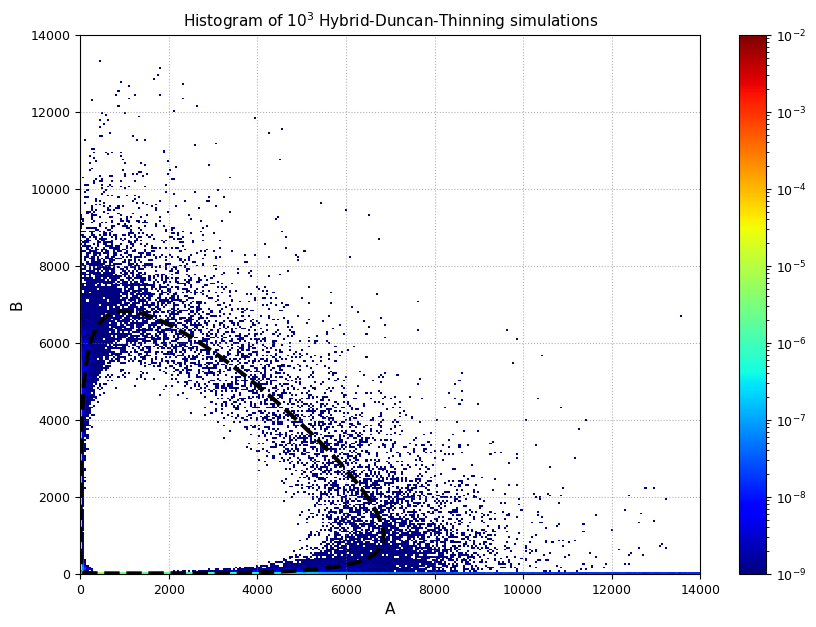

In [18]:
# Simulation Hybrid-Duncan-Thinning auf Lotka-Volterra + Trajectorie Distribution
import matplotlib.colors as colors
from tqdm import tqdm
import matplotlib.pyplot as plt

t0 = 0
tf = 5
n = 1000
boundaries = np.array([25.0,35.0,25.0,35.0])
k1 = 2.0
k2 = 0.002
k3 = 2.0
A0 = 50
B0 = 60
Delta_t = 5*10**(-3)
delta_t = 5*10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2])
S = np.array([[1,-1,0],[0,1,-1]])
S_ed = np.array([[1,1,0],[0,1,1]],dtype=int)
c = np.array([k1,k2,k3])
x0 = np.array([A0,B0])
lambda_bounds = np.array([60,550,60])
result_duncan_thinning = []
for i in tqdm(range(n)):
    t,z = stochastinetics.hybrid_duncan_thinning(S,S_ed,c,t0,x0,tf,delta_t,Delta_t,boundaries,lambda_bounds)
    result_duncan_thinning.append([t,z[:,0],z[:,1]])
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_duncan_thinning_stepsize_5_10_3.csv")
stochastinetics.save_sim_results(result_duncan_thinning,path)
  
all_A = np.concatenate([traj[1] for traj in result_duncan_thinning])
all_B = np.concatenate([traj[2] for traj in result_duncan_thinning])
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)

fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3)
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_title('Histogram of $10^3$ Hybrid-Duncan-Thinning simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
#path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_duncan_thinning_{boundaries[0]}_{boundaries[1]}.png")
#plt.savefig(path)
plt.show()

Starte mit SSA
1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 sim

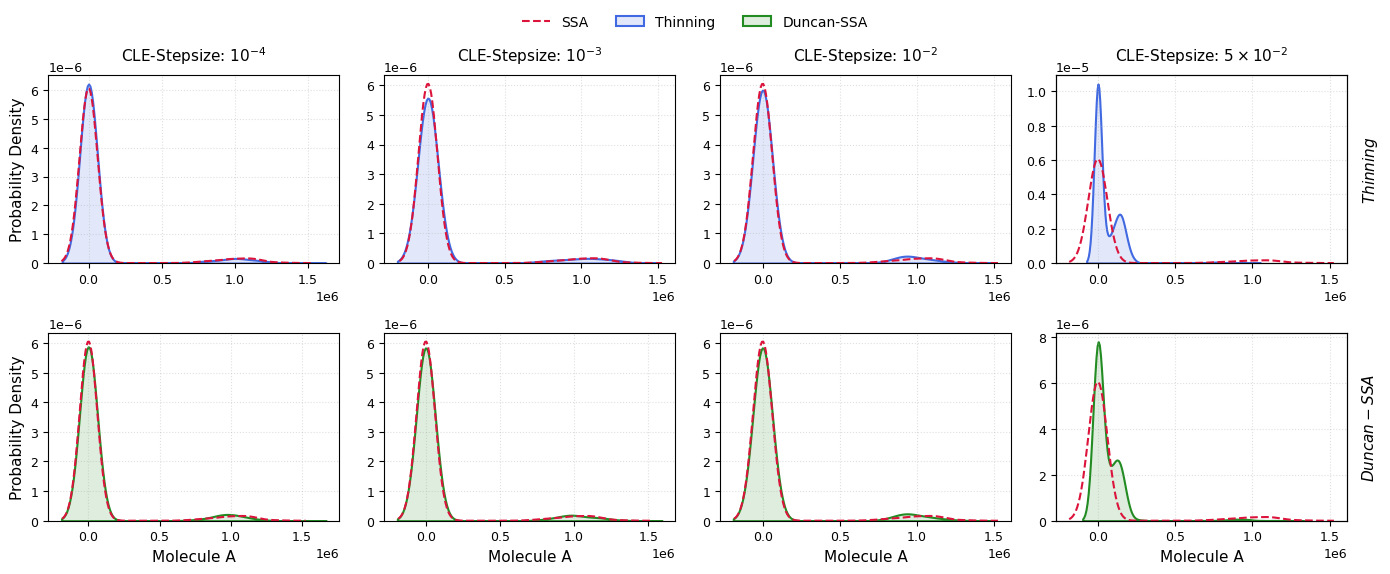

Tests Thinning Method
MannwhitneyuResult(statistic=np.float64(485696.5), pvalue=np.float64(0.26733255001770073))
MannwhitneyuResult(statistic=np.float64(494314.0), pvalue=np.float64(0.6592838861838888))
MannwhitneyuResult(statistic=np.float64(563743.0), pvalue=np.float64(3.507636510491682e-07))
MannwhitneyuResult(statistic=np.float64(200744.5), pvalue=np.float64(6.328996503517234e-119))
Tests Duncan SSA
MannwhitneyuResult(statistic=np.float64(503430.0), pvalue=np.float64(0.7897675183324958))
MannwhitneyuResult(statistic=np.float64(510481.0), pvalue=np.float64(0.4154687098505988))
MannwhitneyuResult(statistic=np.float64(548457.0), pvalue=np.float64(0.00011157018316730243))
MannwhitneyuResult(statistic=np.float64(200744.5), pvalue=np.float64(6.328996503517234e-119))


In [13]:
# probability dist für verschiedene Step Sizes

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    i = 0
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[i,2*j:2*j+2] = current_result[1][idx].copy()
        i+=1
    return data

def data_preprocessing(paths,time_points):
    datas = [np.zeros((1000,2*len(time_points))) for i in paths]
    for i,data in enumerate(datas):
        print(f"Starte mit {os.path.basename(paths[i])}")
        datas[i] = fill_time_dict_gen(data,paths[i],3,1000,time_points)
        datas[i] = datas[i][:,np.array([True if i%2==0 else False for i in range(datas[i].shape[1])])]
    return datas

time_points = np.linspace(1,5,1000)

path_ssa= "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_ssa.csv"
data_ssa = np.zeros((1000,2*len(time_points)))
print("Starte mit SSA")
data_ssa = fill_time_dict_gen(data_ssa, path_ssa,3,1000,time_points)
data_ssa2 = data_ssa[:,np.array([True if i%2==0 else False for i in range(data_ssa.shape[1])])]


paths_thinning = ["/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_thinning_stepsize_10_4.csv",
                  "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_thinning_25.0_35.0.csv",
                  "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_thinning_stepsize_10_2.csv",
                  "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_thinning_stepsize_5_10_2.csv"]

paths_duncan = ["/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_ssa_stepsize_10_4.csv",
                "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_15.0_25.0.csv",
                "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_thinning_stepsize_10_2.csv",
                "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_duncan_ssa_stepsize_5_10_2.csv"]

thinning_datasets = data_preprocessing(paths_thinning,time_points)
duncan_datasets = data_preprocessing(paths_duncan, time_points)

plt.rcParams.update({'font.size': 10,'axes.labelsize': 11,'axes.titlesize': 11,'xtick.labelsize': 9,'ytick.labelsize': 9,'grid.alpha': 0.4,'grid.linestyle': ':'})

idx = np.searchsorted(time_points, 5)
stepsizes = [r"$10^{-4}$", r"$ 10^{-3}$",r"$ 10^{-2}$",r"$5 \times 10^{-2}$"]
method = ["Thinning", "Duncan-SSA"]
n_cols = len(stepsizes)
n_rows = 2


cle_currs = []

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 2.8 * n_rows), sharex=False, sharey=False)

data_ssa3 = data_ssa2[:, -1]
data_ssa4 = data_ssa3[data_ssa3 >= 15000]

data_currs_thinning = []
data_currs_duncan = []
color_ssa = "crimson"
color_thinning = "royalblue"
color_duncan = "forestgreen" 

for j in range(2):
    for k in range(n_cols):
        ax = axes[j, k]

        if j == 0:
            data_curr = thinning_datasets[k][:, idx]
            data_currs_thinning.append(data_curr)
            curr_color = color_thinning
            curr_label = "Thinning"
        elif j == 1:
            data_curr = duncan_datasets[k][:, idx]
            data_currs_duncan.append(data_curr)
            curr_color = color_duncan
            curr_label = "Duncan-SSA"
        

        sns.kdeplot(data_ssa3, ax=ax, color=color_ssa, linestyle="--", label="SSA", linewidth=1.5)
        sns.kdeplot(data_curr, ax=ax, color=curr_color, label=curr_label, linewidth=1.5, fill=True, alpha=0.15)

        ax.grid(True)
        ax.set_ylabel("")
        ax.set_xlabel("")

        if k == len(thinning_datasets) - 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"${method[j]}$", fontsize=11, labelpad=10)
            ax2.set_yticks([])

for k, step_str in enumerate(stepsizes):
    axes[0, k].set_title(f"CLE-Stepsize: {step_str}", pad=10)

for row_idx in range(n_rows):
    axes[row_idx, 0].set_ylabel("Probability Density")

for col_idx in range(n_cols):
    axes[-1, col_idx].set_xlabel("Molecule A")

handles_dict = {}
for row in range(n_rows):
    h, l = axes[row, 0].get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in handles_dict:
            handles_dict[label] = handle

fig.legend(
    handles_dict.values(), 
    handles_dict.keys(), 
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.03), 
    ncol=3, 
    frameon=False
)

plt.tight_layout()
fig.subplots_adjust(top=0.90)

plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/thinning_vs_duncan_prob_dist.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tests Thinning Method")
print(stats.mannwhitneyu(data_ssa3,data_currs_thinning[0]))
print(stats.mannwhitneyu(data_ssa3,data_currs_thinning[1]))
print(stats.mannwhitneyu(data_ssa3,data_currs_thinning[3]))
print(stats.mannwhitneyu(data_ssa3,data_currs_thinning[2]))

print("Tests Duncan SSA")
print(stats.mannwhitneyu(data_ssa3,data_currs_duncan[0]))
print(stats.mannwhitneyu(data_ssa3,data_currs_duncan[1]))
print(stats.mannwhitneyu(data_ssa3,data_currs_duncan[3]))
print(stats.mannwhitneyu(data_ssa3,data_currs_duncan[2]))


### Hybrid-Alfonsi

100%|██████████| 1000/1000 [08:27<00:00,  1.97it/s]


Time elapsed: 511.83936977386475 seconds.


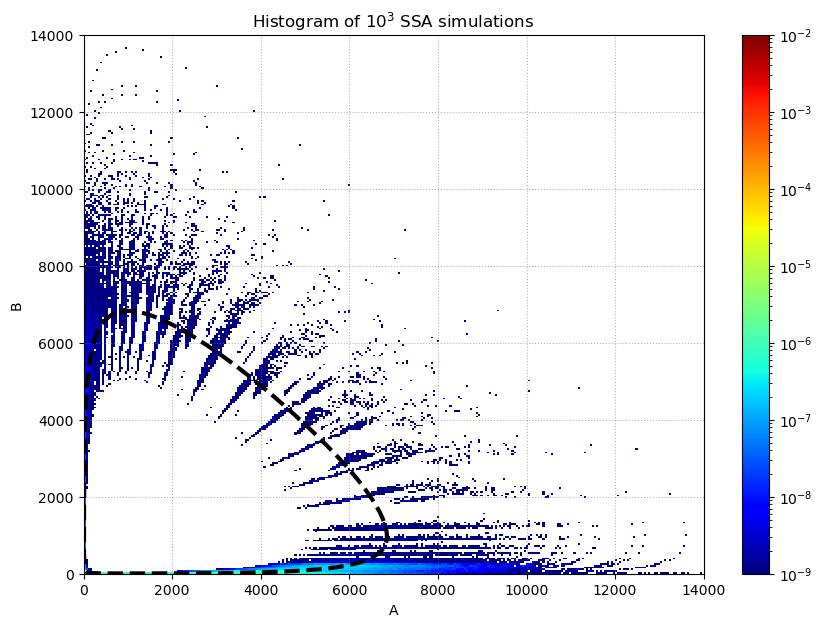

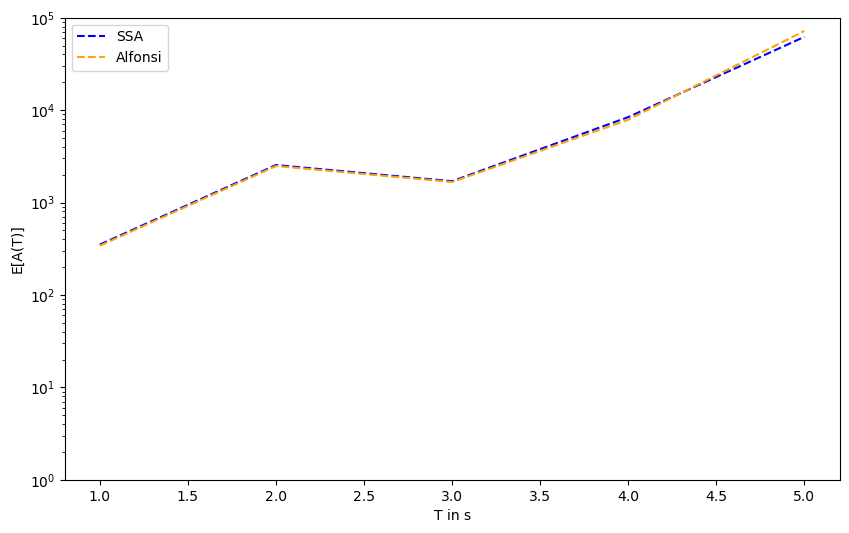

In [9]:
from tqdm import tqdm
import time
import matplotlib.colors as colors

t0 = 0
tf = 5
n = 1000
threshold = 500
result_gillespie = []

start = time.time()

for i in tqdm(range(n)):
    t,z = stochastinetics.hybrid(S,S_ed,c,t0,x0,tf,threshold)
    result_gillespie.append([t,z])

path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_gillespie_500.csv")
stochastinetics.save_sim_results(result_gillespie,path)

end = time.time()    
all_A = np.concatenate([traj[1][:,0] for traj in result_gillespie])
all_B = np.concatenate([traj[1][:,1] for traj in result_gillespie])

print(f"Time elapsed: {end-start} seconds.")
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_A, all_B, bins=300,range=[[0, 14000], [0, 14000]],norm=colors.LogNorm(vmin=1e-9, vmax=1e-2),cmap='jet', density=True)
fig.colorbar(h[3], ax=ax)
ax.plot(x, y, color='black', linestyle='--', linewidth=3)
ax.set_xlim(0, 14000)
ax.set_ylim(0, 14000)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_title('Histogram of $10^3$ SSA simulations')
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
plt.show()


# Expectation Value over Time --> run cle-simulation in advance!

# folder = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
# result_ssa = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_ssa.csv"),3)
# result_alfonsi_500 = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_gillespie_500.csv"),3)

t_range = np.arange(1,6)

ssa_exp = stochastinetics.expectation(result_ssa,n,t_range)
alfonsi_exp = stochastinetics.expectation(result_gillespie,n,t_range)

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(t_range,ssa_exp[:,0],color="blue", ls="--",label="SSA")
ax.plot(t_range,alfonsi_exp[:,0],color="orange", ls="--",label="Alfonsi")
ax.set_ylabel(r"E[A(T)]")
ax.set_xlabel("T in s")
ax.set_yscale('log')
ax.set_ylim(1, 100000)
ax.legend()
# path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_comparison_E[B]_15.0_25.0.png")
# plt.savefig(path)
plt.show()

In [41]:
len(result_gillespie)

0

### Reproducing Figure 3 (a) and (b) with SSA, CLE and Hybrid results

1000 simulation runs have been reconstructed succesfully.


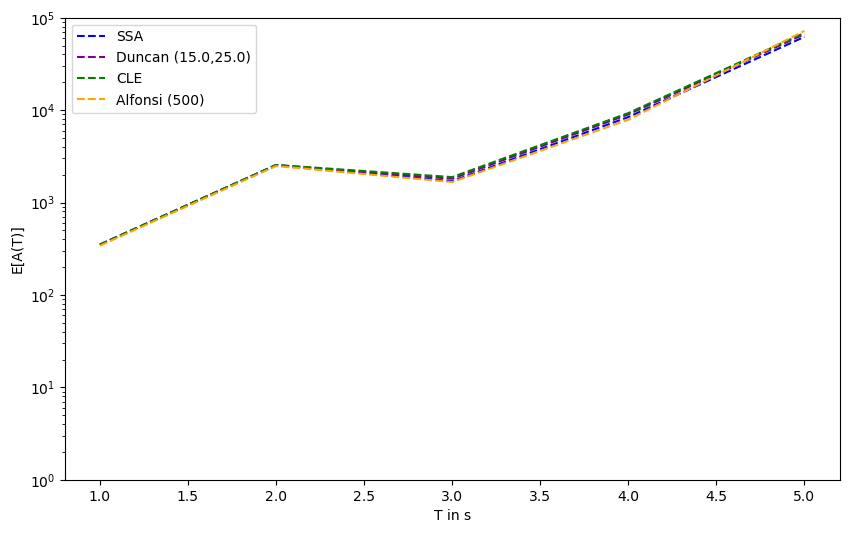

In [ ]:
# Expectation Value over Time --> run cle-simulation in advance!

folder = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
result_cle = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_cle_dilisecond2.csv"),3)
result_ssa = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_ssa.csv"),3)
result_duncan_15_25 = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_duncan_15.0_25.0.csv"),3)
result_alfonsi = stochastinetics.read_in_sim_results(os.path.join(folder,"result_lotka_volterra_gillespie_500.csv"),3)

t_range = np.arange(1,6)

ssa_exp = stochastinetics.expectation(result_ssa,n,t_range)
duncan_exp_15 = stochastinetics.expectation(result_duncan_15_25,n,t_range)
cle_exp = stochastinetics.expectation(result_cle,100,t_range)
alfonsi_exp = stochastinetics.expectation(result_alfonsi,n,t_range)

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(t_range,ssa_exp[:,0],color="blue", ls="--",label="SSA")
ax.plot(t_range,duncan_exp_15[:,0],color="purple", ls="--",label="Duncan (15.0,25.0)")
ax.plot(t_range,cle_exp[:,0],color="green", ls="--",label="CLE")
ax.plot(t_range,alfonsi_exp[:,0],color="orange", ls="--",label="Alfonsi (500)")
ax.set_ylabel(r"E[A(T)]")
ax.set_xlabel("T in s")
ax.set_yscale('log')
ax.set_ylim(1, 100000)
ax.legend()
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_comparison_E[A].png")
plt.savefig(path)
plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10896/566768464.py:52: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
/tmp/ipykernel_10896/566768464.py:67: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
Parameter 640: 100%|██████████| 1000/1000 [20:31<00:00,  1.23s/it]


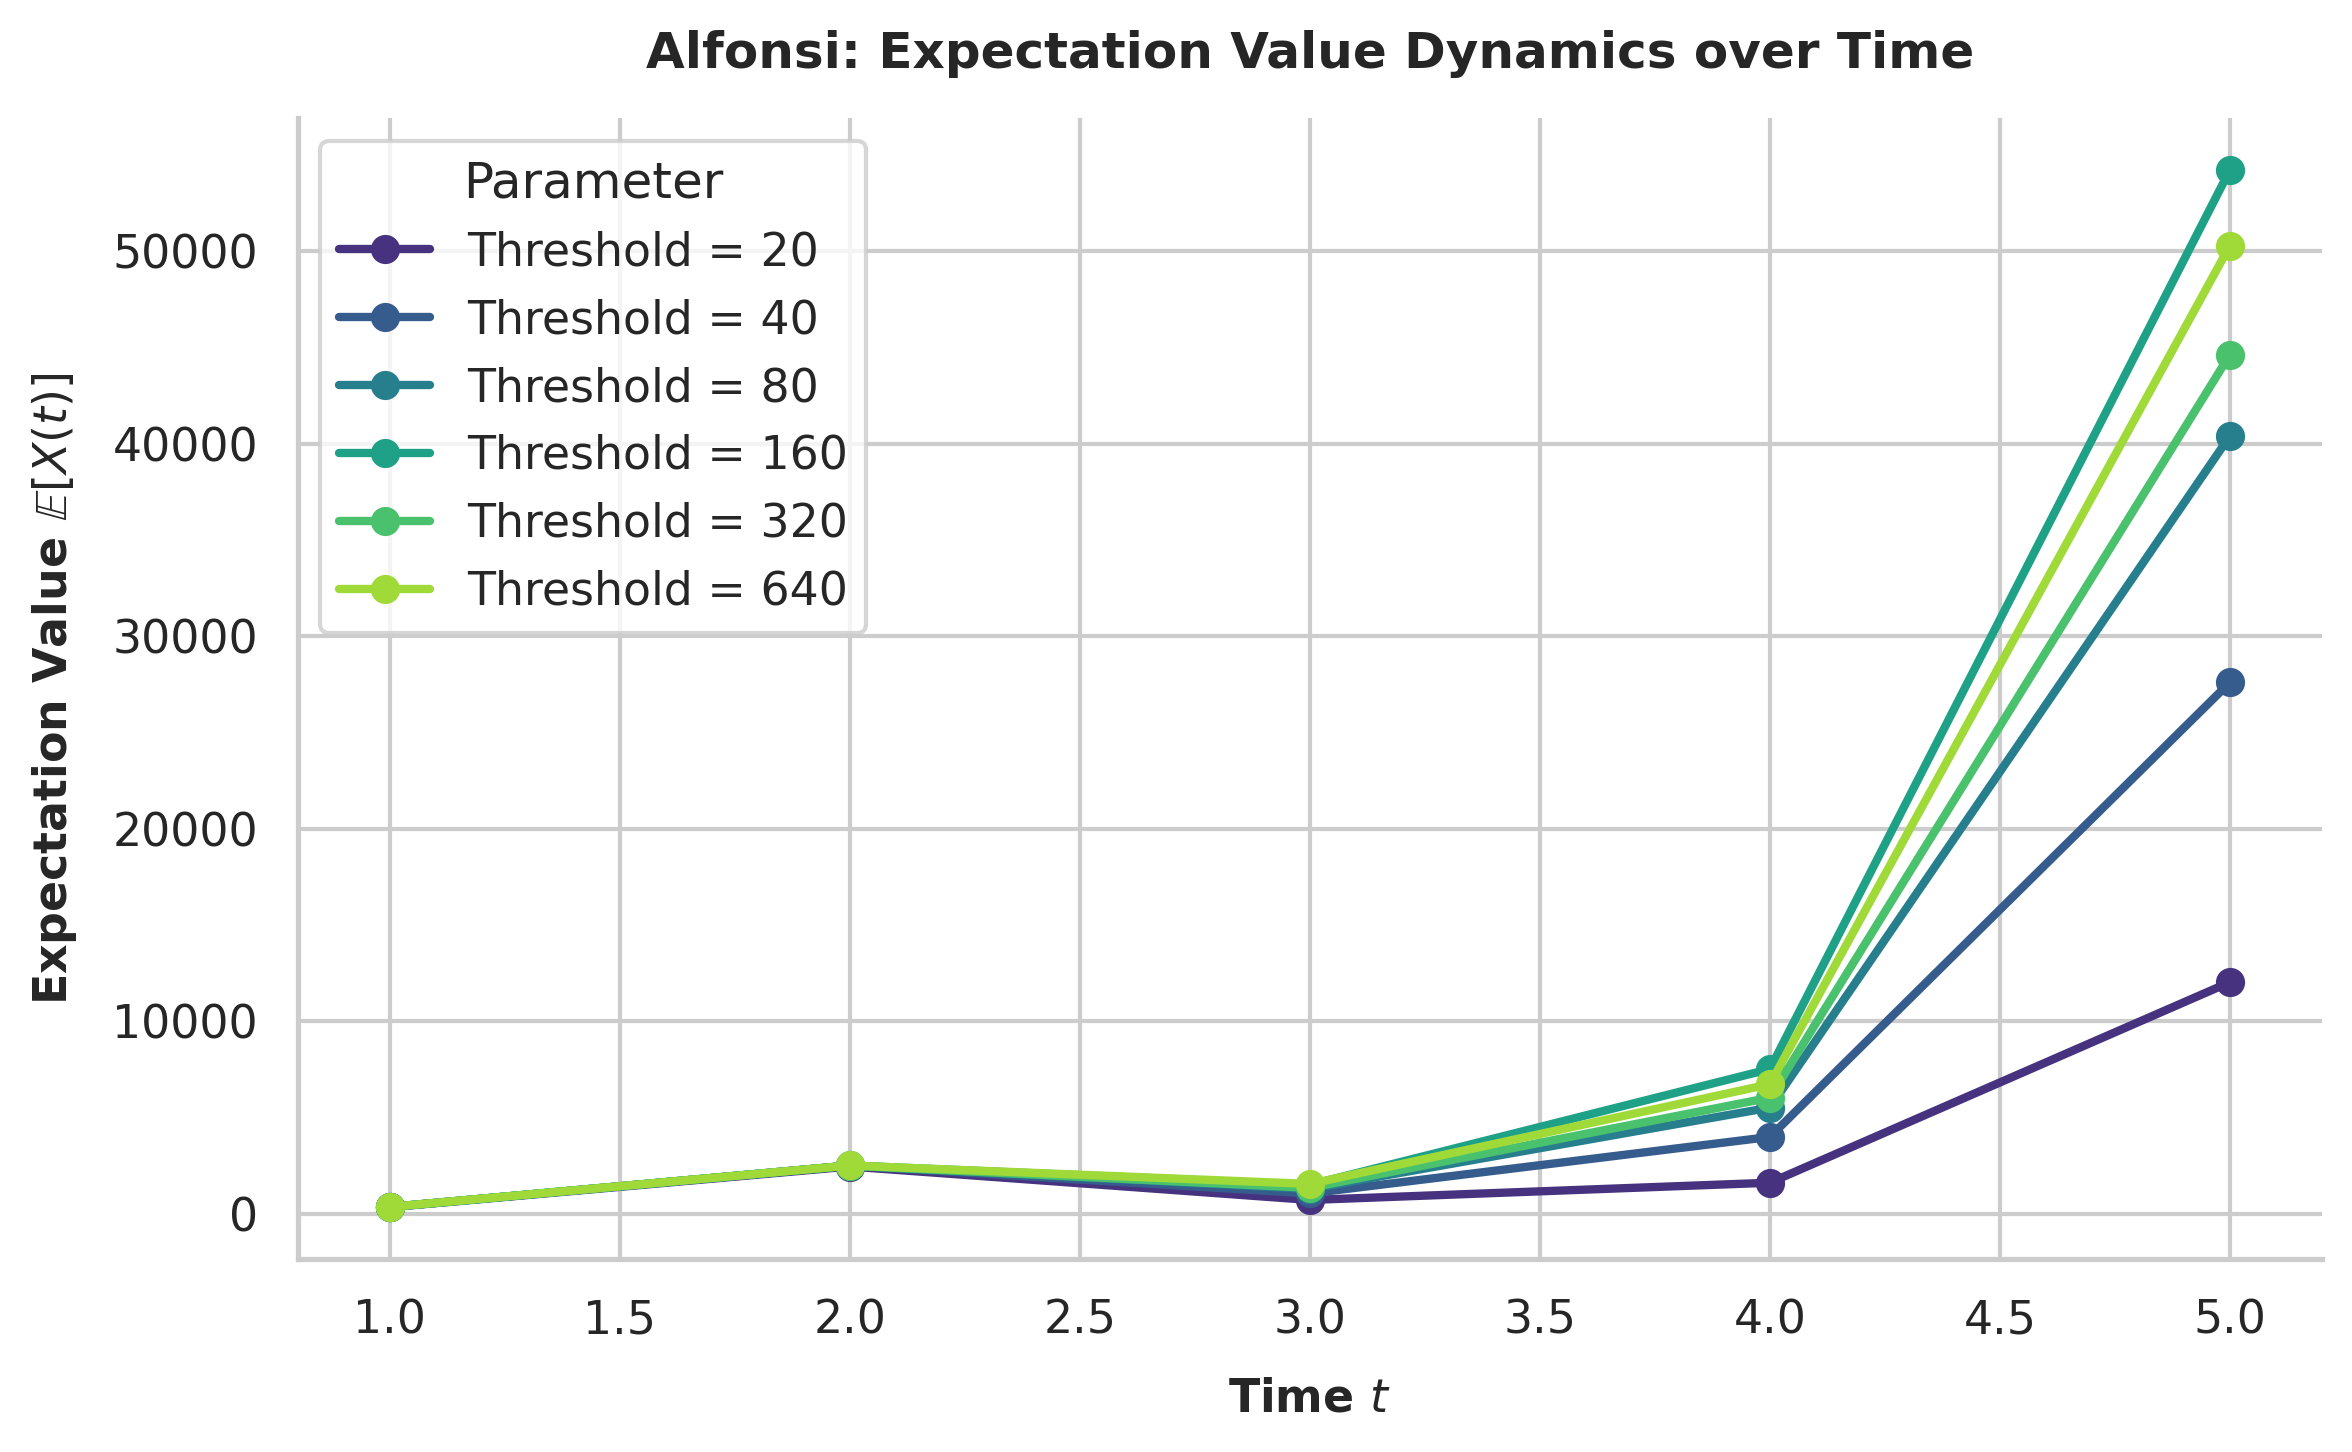

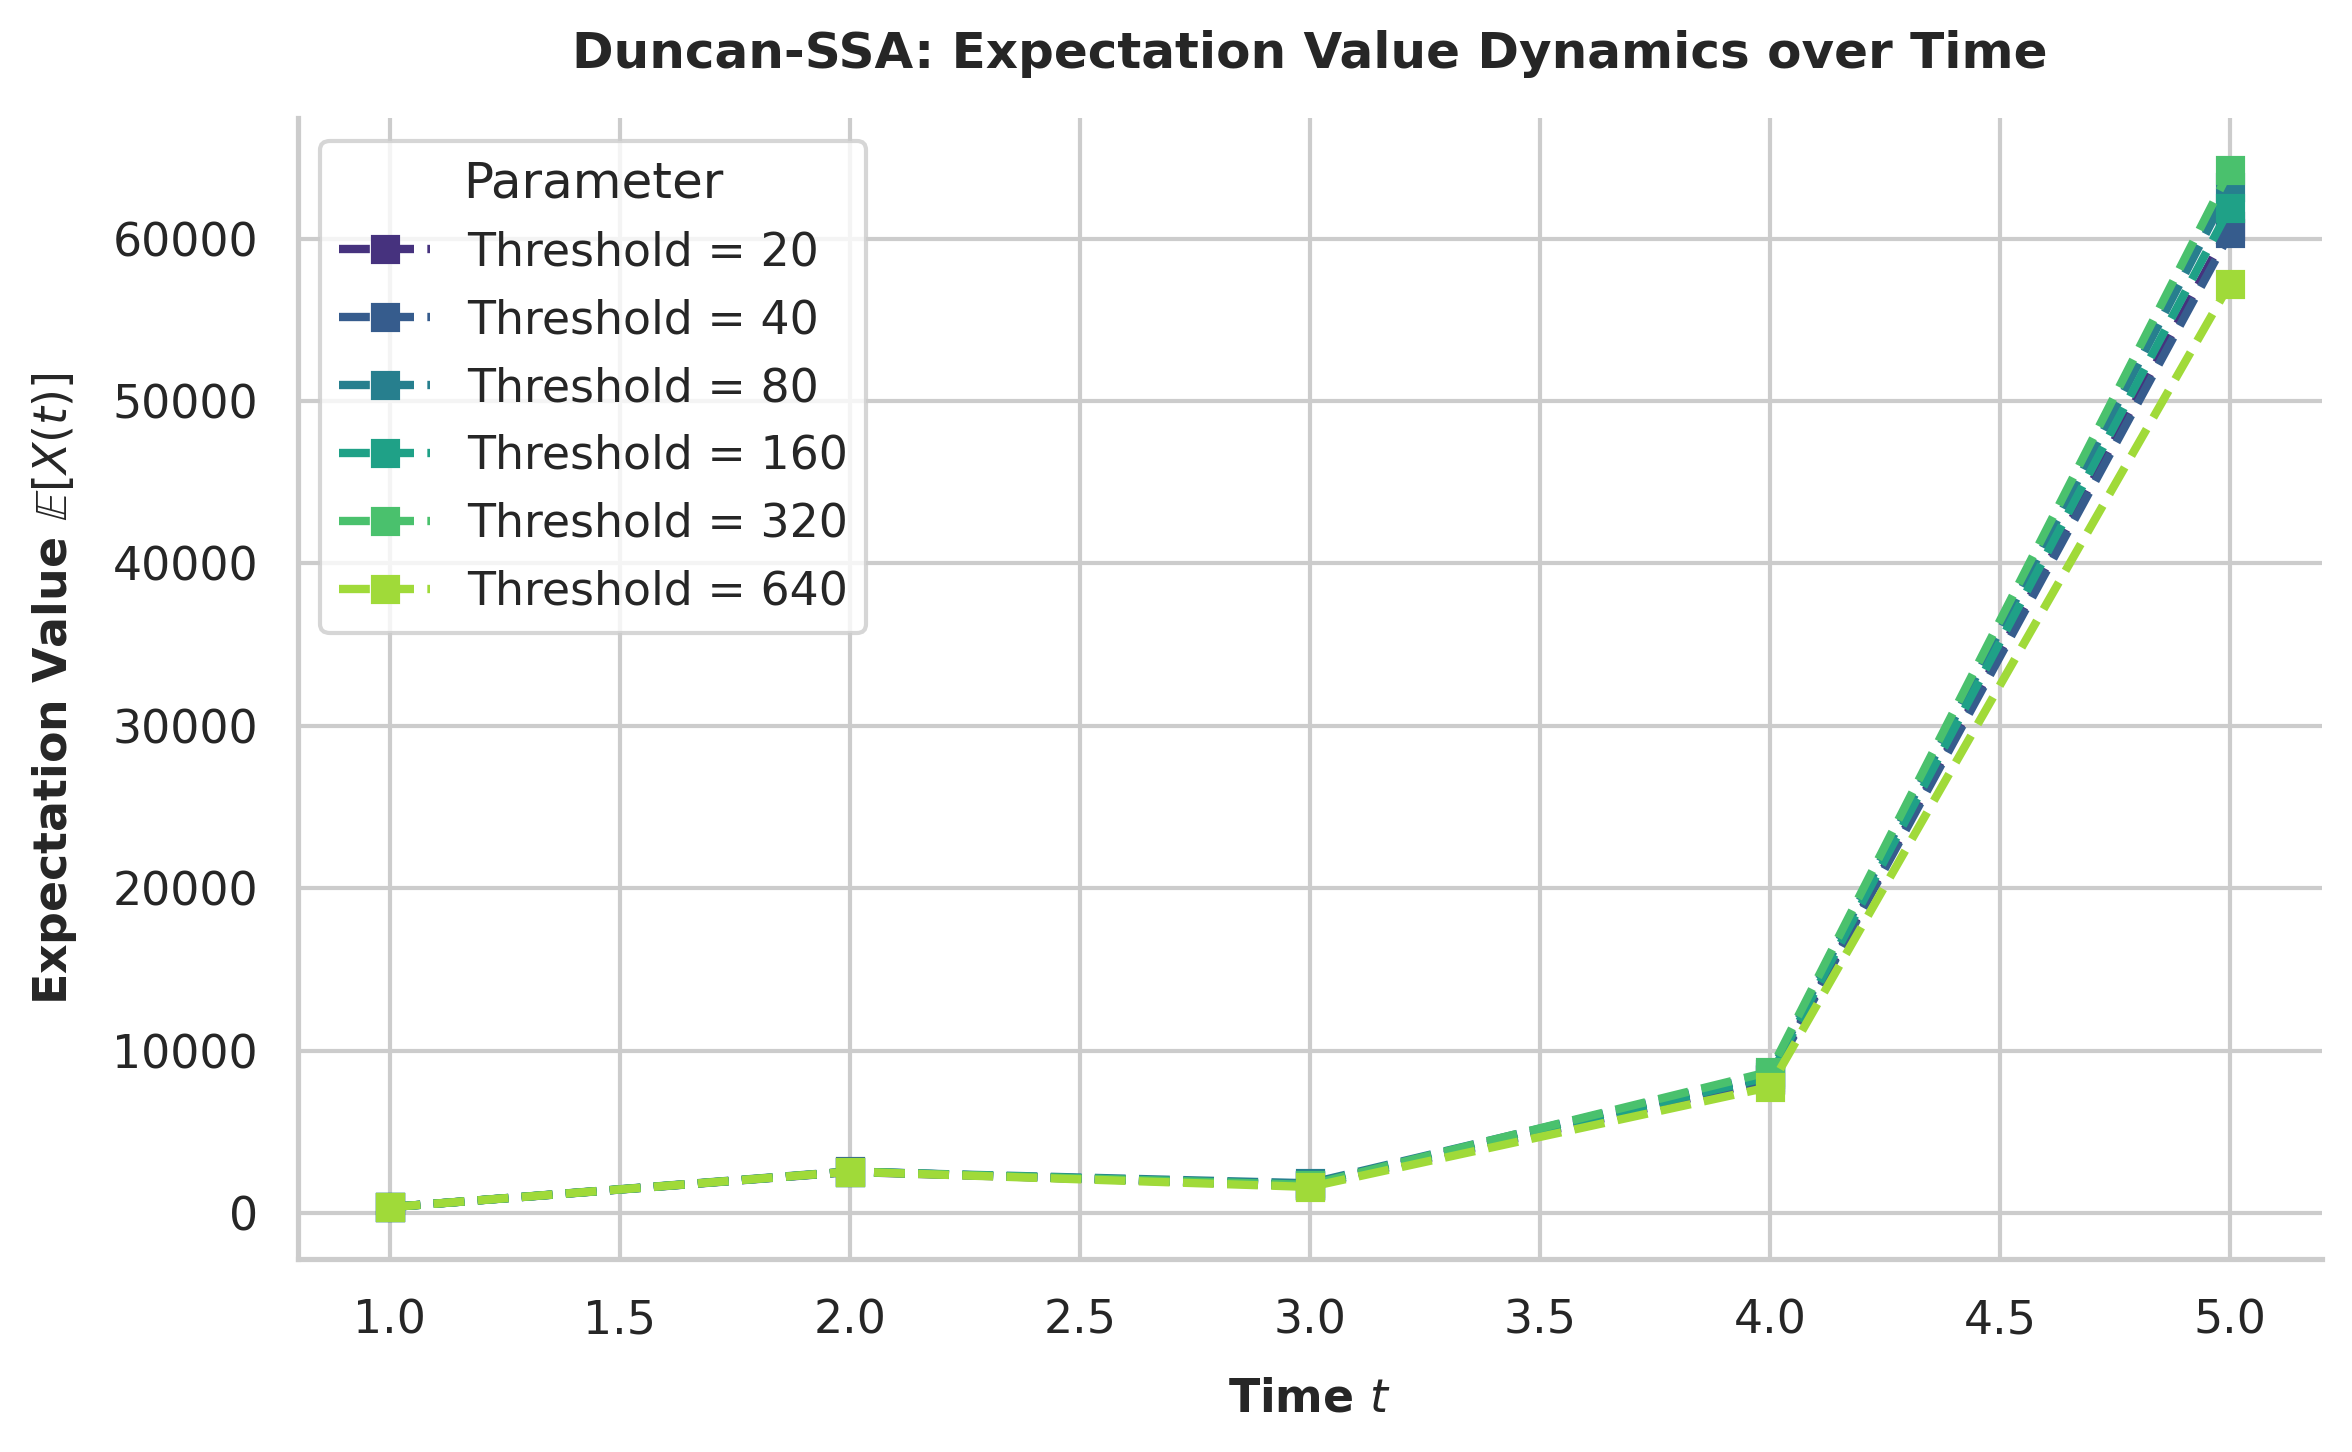

In [25]:
# Erwartungswert abhängig von Parametern

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

parameter_values = [20, 40, 80, 160, 320, 640]
t_range = np.arange(1, 6)
t_max = np.max(t_range) + 0.01

n=1000
t0 = 0
tf = 5

exp_comparison_alfonsi = np.zeros((len(parameter_values), len(t_range)))
exp_comparison_duncan = np.zeros((len(parameter_values), len(t_range)))

for k, para in enumerate(parameter_values):
    sum_alfonsi = np.zeros(len(t_range))
    sum_duncan = np.zeros(len(t_range))
    
    boundaries = np.array([para * 0.5, para, para * 0.5, para])
    
    for i in tqdm(range(n), desc=f"Parameter {para}"):
        t_alf, z_alf = stochastinetics.hybrid(S, S_ed, c, t0, x0, t_max, part=para)
        z_alf_vals = z_alf[:, 0] if z_alf.ndim > 1 else z_alf
        
        t_dunc, z_dunc = stochastinetics.hybrid_duncan_ssa(S, S_ed, c, t0, x0, t_max, delta_t, Delta_t, boundaries)
        z_dunc_vals = z_dunc[:, 0] if z_dunc.ndim > 1 else z_dunc
        
        for j, tj in enumerate(t_range):
            idx_alf = max(0, np.searchsorted(t_alf, tj, side='right') - 1)
            idx_dunc = max(0, np.searchsorted(t_dunc, tj, side='right') - 1)
            
            sum_alfonsi[j] += z_alf_vals[idx_alf]
            sum_duncan[j] += z_dunc_vals[idx_dunc]
            
    exp_comparison_alfonsi[k, :] = sum_alfonsi / n
    exp_comparison_duncan[k, :] = sum_duncan / n

sns.set_theme(style="whitegrid", font="sans-serif")
# --- PLOT 1: REIN ALFONSI ---
fig1, ax1 = plt.subplots(figsize=(8, 5), dpi=300)
colors = sns.color_palette("viridis", n_colors=len(parameter_values))

for k, para in enumerate(parameter_values):
    ax1.plot(t_range, exp_comparison_alfonsi[k, :], marker='o', color=colors[k], 
             linewidth=2, label=f"Threshold = {para}")

ax1.set_xlabel("Time $t$", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title("Alfonsi: Expectation Value Dynamics over Time", fontsize=12, fontweight='bold', pad=12)
ax1.legend(title="Parameter", frameon=True, facecolor='white', loc='best')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

# --- PLOT 2: REIN DUNCAN ---
fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=300)

for k, para in enumerate(parameter_values):
    ax2.plot(t_range, exp_comparison_duncan[k, :], marker='s', linestyle='--', color=colors[k], 
             linewidth=2, label=f"Threshold = {para}")

ax2.set_xlabel("Time $t$", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_title("Duncan-SSA: Expectation Value Dynamics over Time", fontsize=12, fontweight='bold', pad=12)
ax2.legend(title="Parameter", frameon=True, facecolor='white', loc='best')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10896/4079078076.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
/tmp/ipykernel_10896/4079078076.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)


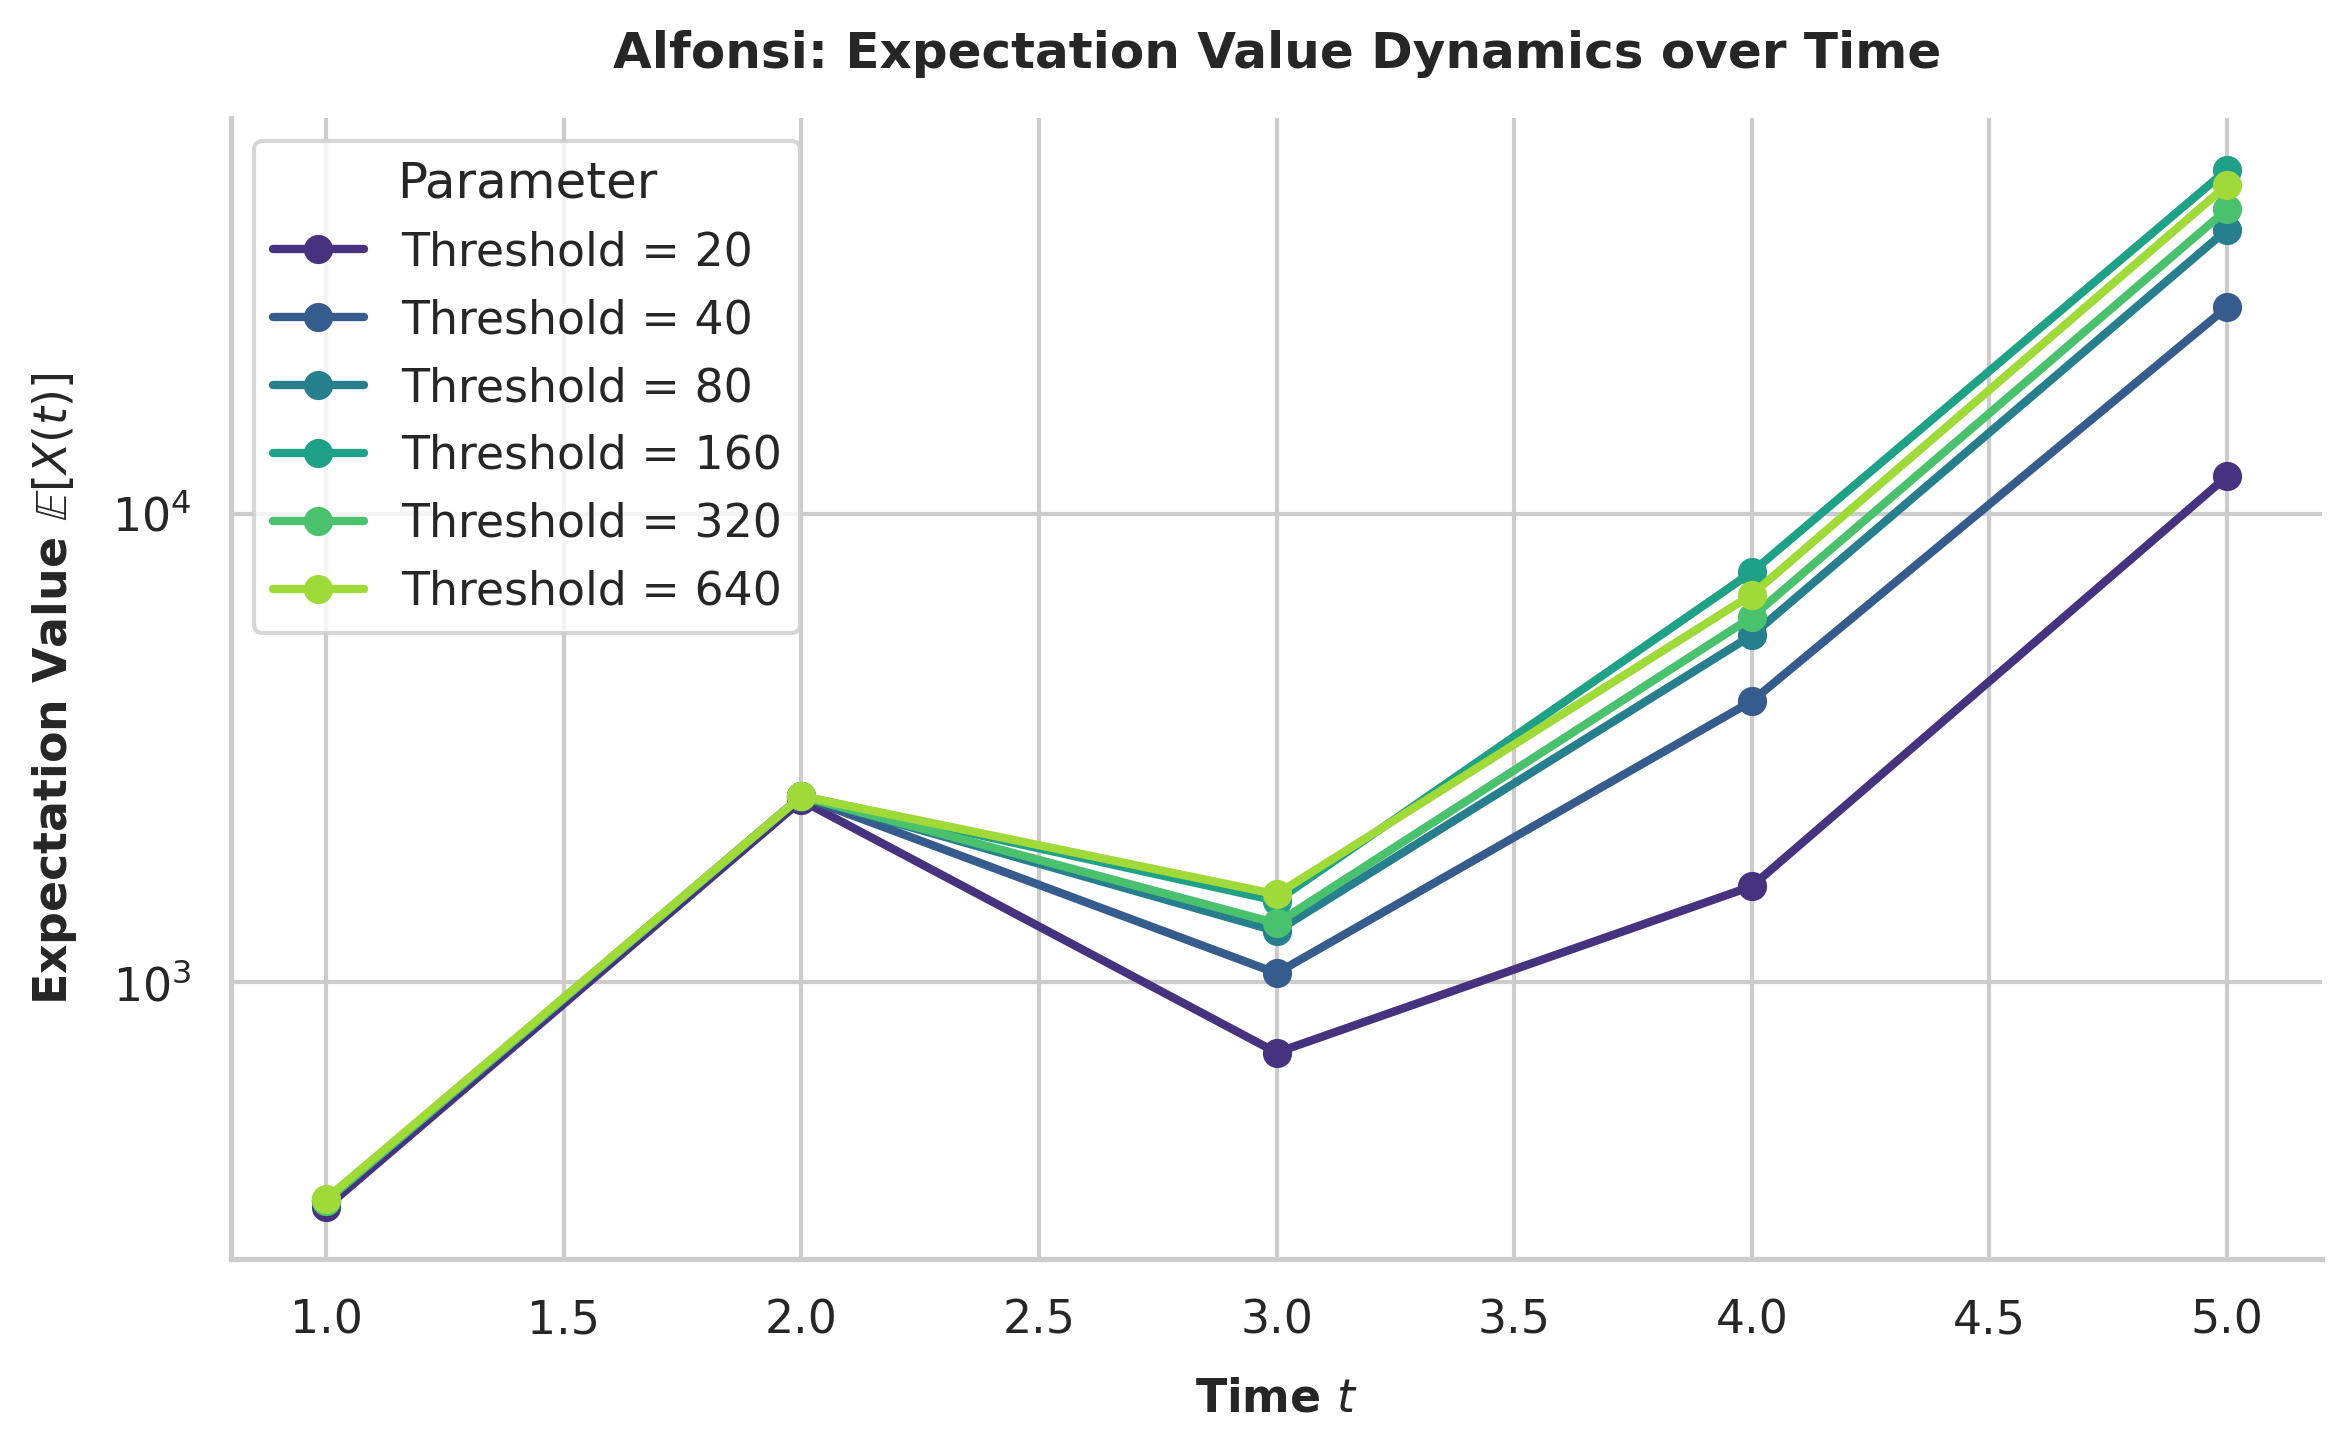

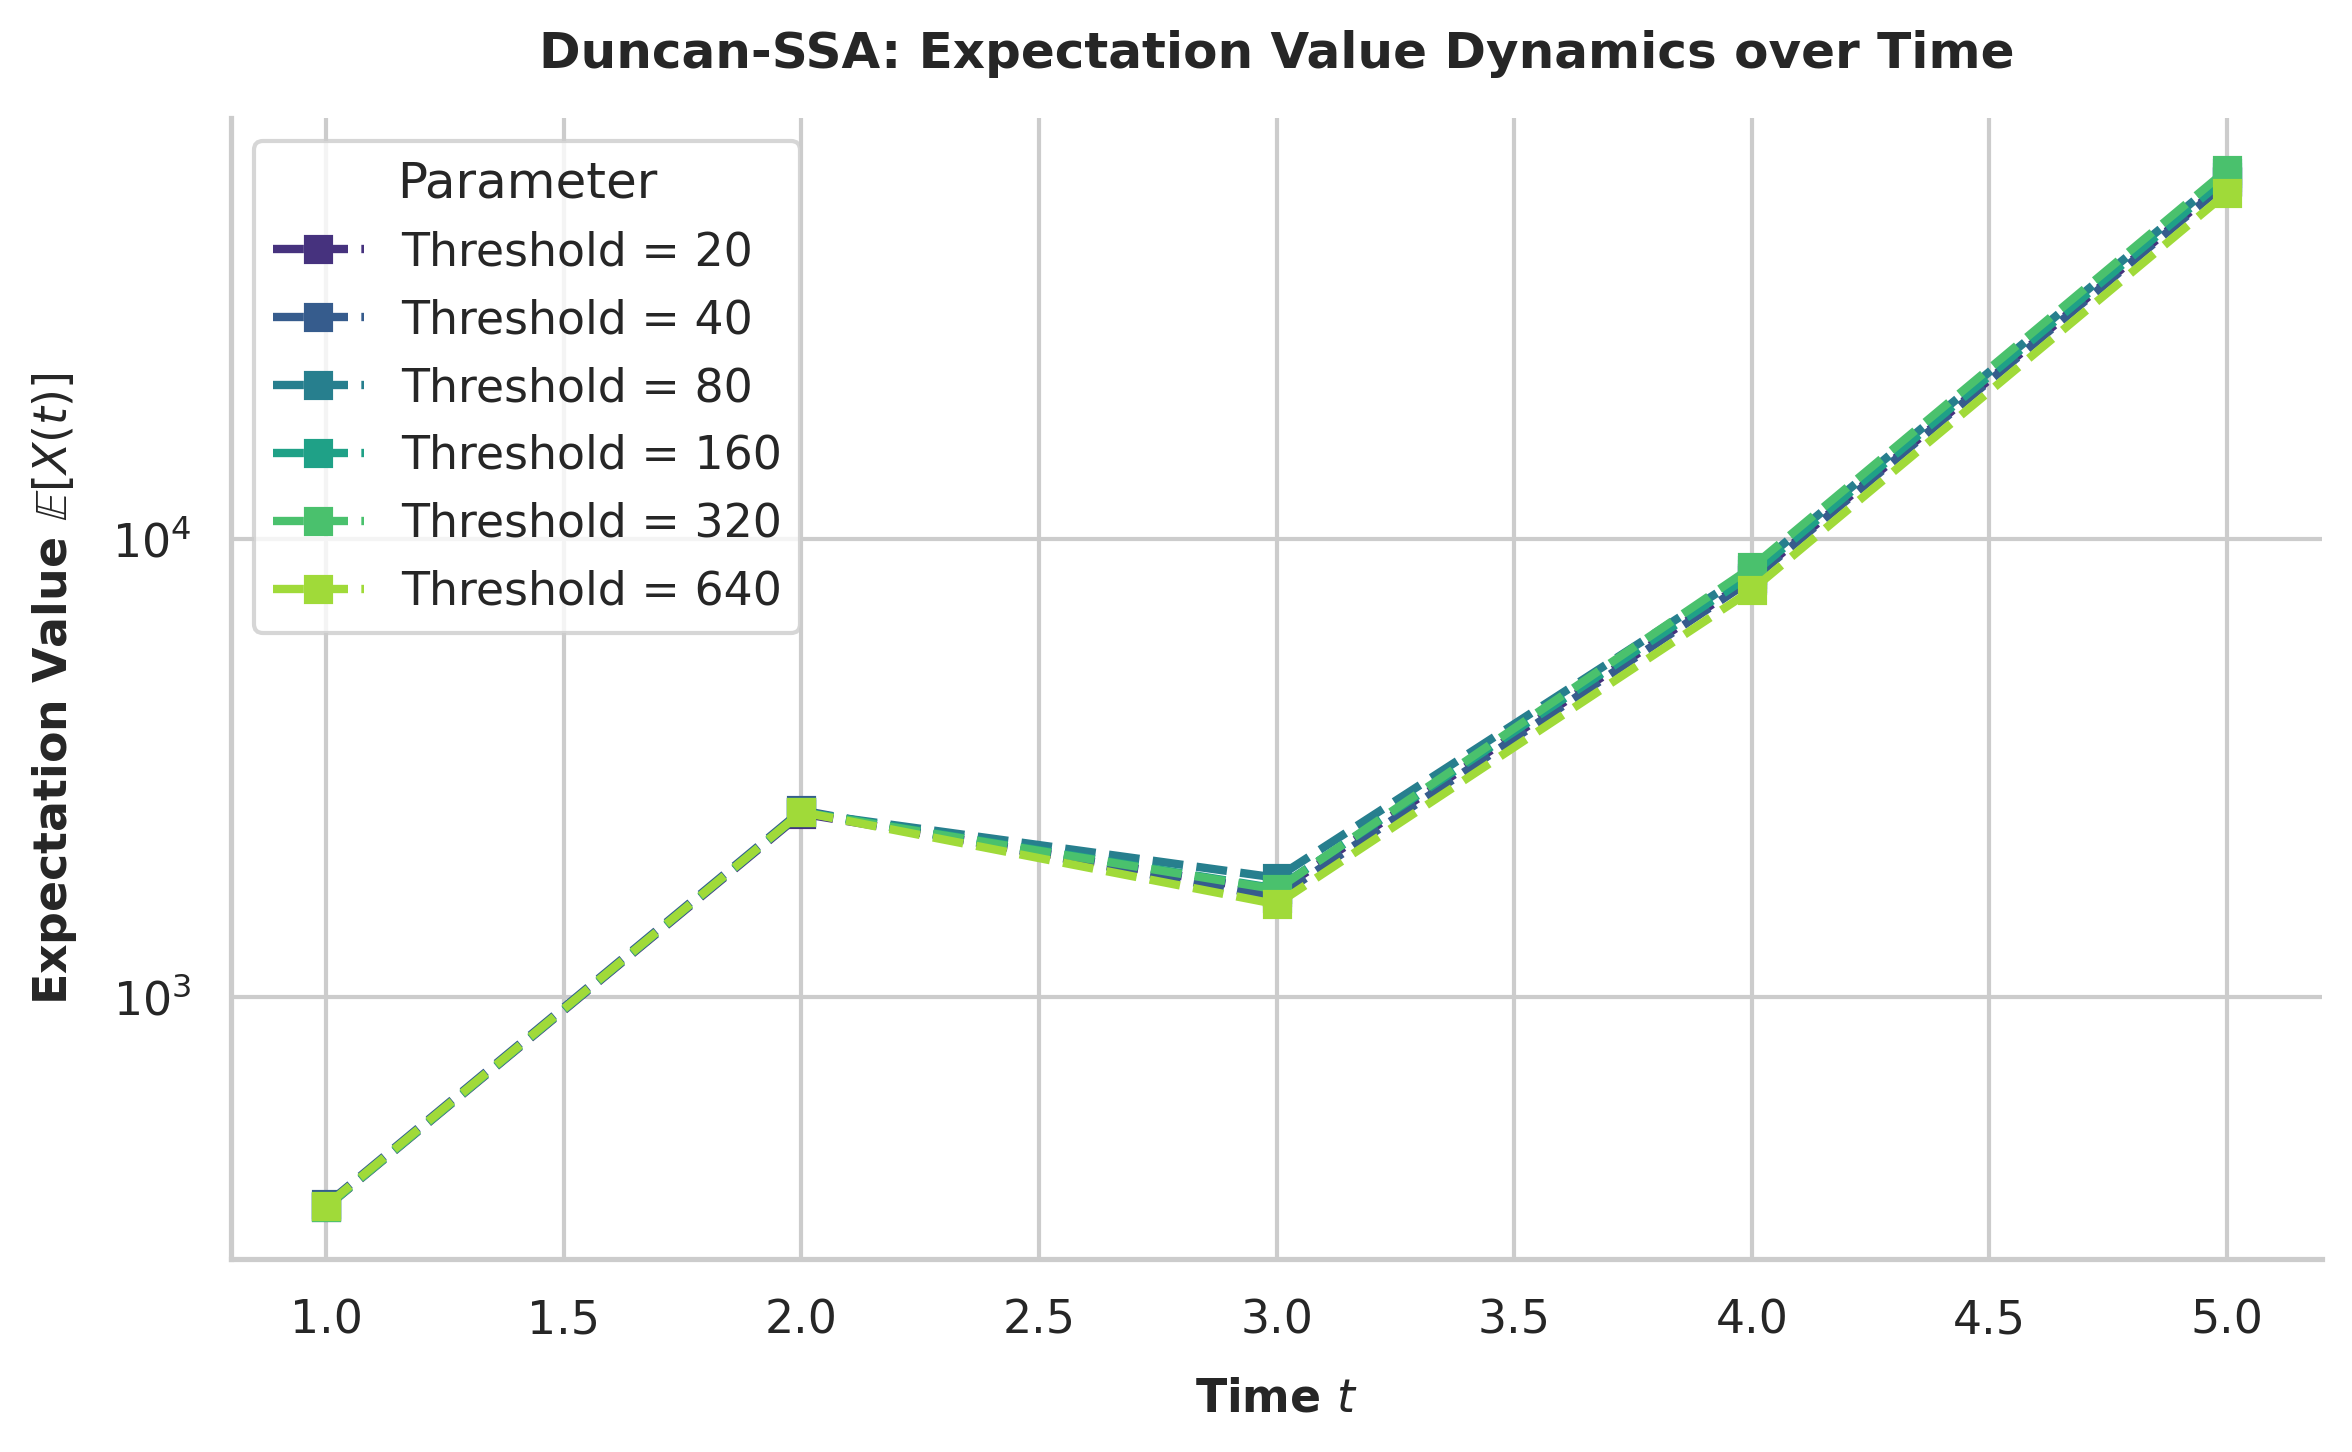

In [27]:
sns.set_theme(style="whitegrid", font="sans-serif")
# --- PLOT 1: REIN ALFONSI ---
fig1, ax1 = plt.subplots(figsize=(8, 5), dpi=300)
colors = sns.color_palette("viridis", n_colors=len(parameter_values))

for k, para in enumerate(parameter_values):
    ax1.plot(t_range, exp_comparison_alfonsi[k, :], marker='o', color=colors[k], 
             linewidth=2, label=f"Threshold = {para}")

ax1.set_xlabel("Time $t$", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title("Alfonsi: Expectation Value Dynamics over Time", fontsize=12, fontweight='bold', pad=12)
ax1.legend(title="Parameter", frameon=True, facecolor='white', loc='best')
ax1.set_yscale('log')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/Final_report/Images/alfonsi_exp_per_para_volterra.png")
plt.show()

# --- PLOT 2: REIN DUNCAN ---
fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=300)

for k, para in enumerate(parameter_values):
    ax2.plot(t_range, exp_comparison_duncan[k, :], marker='s', linestyle='--', color=colors[k], 
             linewidth=2, label=f"Threshold = {para}")

ax2.set_xlabel("Time $t$", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel("Expectation Value $\mathbb{E}[X(t)]$", fontsize=11, fontweight='bold', labelpad=8)
ax2.set_title("Duncan-SSA: Expectation Value Dynamics over Time", fontsize=12, fontweight='bold', pad=12)
ax2.legend(title="Parameter", frameon=True, facecolor='white', loc='best')
ax2.set_yscale('log')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/Final_report/Images/duncan_exp_per_para_volterra.png")
plt.show()

In [ ]:
# Average Computation Time over Simulation Duration
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


t0 = 0
n = 1000
t_range = np.arange(1,7)  
comp_times_ssa = []
comp_times_cle = []
comp_times_duncan_02_12 = []
comp_times_duncan_10_90 = []
comp_times_duncan_80_90 = []
comp_times_duncan_5_15 = []
comp_times_duncan_10_20 = []
comp_times_duncan_15_25 = []
comp_times_gillespie = []
threshold = 500


for sim_time in t_range:
#    --- CLE ---
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: CLE")
    for i in tqdm(range(n)):
        t,z = stochastinetics.cle_trajectory(S,S_ed,c,t0,x0,sim_time,delta_t)
    end = time.time()
    comp_times_cle.append((end-start)/n)

#    --- Hybrid-Duncan ---

    #    --- 5,15 ---
    boundaries = np.array([5.0,15.0,5.0,15.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_5_15.append((end-start)/n)

        # --- 10,20 ---
    boundaries = np.array([10.0,20.0,10.0,20.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_10_20.append((end-start)/n)

        # --- 15,25 --- 
    boundaries = np.array([15.0,25.0,15.0,25.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_15_25.append((end-start)/n)

        # --- 80,90 --- 
    boundaries = np.array([80.0,90.0,80.0,90.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_80_90.append((end-start)/n)

        # --- 10,90 --- 
    boundaries = np.array([10.0,90.0,10.0,90.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_10_90.append((end-start)/n)

        # --- 02,12 --- 
    boundaries = np.array([2.0,12.0,2.0,12.0])
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Hybrid-Duncan")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,sim_time,delta_t,Delta_t,boundaries)
    end = time.time()
    comp_times_duncan_02_12.append((end-start)/n)

    # --- Alfonsi ---
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: Alfonsi")
    for i in tqdm(range(n)):
        t,z = stochastinetics.hybrid(S,S_ed,c,t0,x0,sim_time,threshold)
    end = time.time()
    comp_times_gillespie.append((end-start)/n)

    # --- SSA ---
    start = time.time()
    print(f"Current simulation time: {sim_time}s, Current algorithm: SSA")
    for i in tqdm(range(n)):
        t,z = stochastinetics.SSA(S,S_ed,c,t0,x0,sim_time)
    end = time.time()
    comp_times_ssa.append((end-start)/n)


fig,ax = plt.subplots(figsize=(10,6))
ax.plot(t_range,comp_times_ssa,color="blue", ls="--",label="SSA")
ax.plot(t_range,comp_times_duncan_5_15,color="red", ls="--",label="Duncan (5,15)")
ax.plot(t_range,comp_times_duncan_10_20,color="turquoise", ls="--",label="Duncan (10,20)")
ax.plot(t_range,comp_times_duncan_15_25,color="purple", ls="--",label="Duncan (15,25)")
ax.plot(t_range,comp_times_gillespie,color="orange", ls="--",label="Alfonsi")
ax.plot(t_range,comp_times_cle,color="green", ls="--",label="CLE")
ax.set_yscale('log')
ax.set_ylim(10**(-5), 10**1)
ax.set_xlabel("Simulation duration (s)")
ax.set_ylabel("Average computation time (s)")
ax.legend()
ax.set_title("Average Computation Time over Simulation Duration")
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
plt.show()

Current simulation time: 1s, Current algorithm: Hybrid-Duncan


100%|██████████| 1000/1000 [01:45<00:00,  9.45it/s]


Current simulation time: 1s, Current algorithm: Hybrid-Duncan


100%|██████████| 1000/1000 [02:11<00:00,  7.62it/s]


Current simulation time: 1s, Current algorithm: Hybrid-Duncan


...

100%|██████████| 1000/1000 [10:20<00:00,  1.61it/s]


Current simulation time: 6s, Current algorithm: Hybrid-Duncan


100%|██████████| 1000/1000 [11:25<00:00,  1.46it/s]


Current simulation time: 6s, Current algorithm: Hybrid-Duncan


100%|██████████| 1000/1000 [05:39<00:00,  2.95it/s]


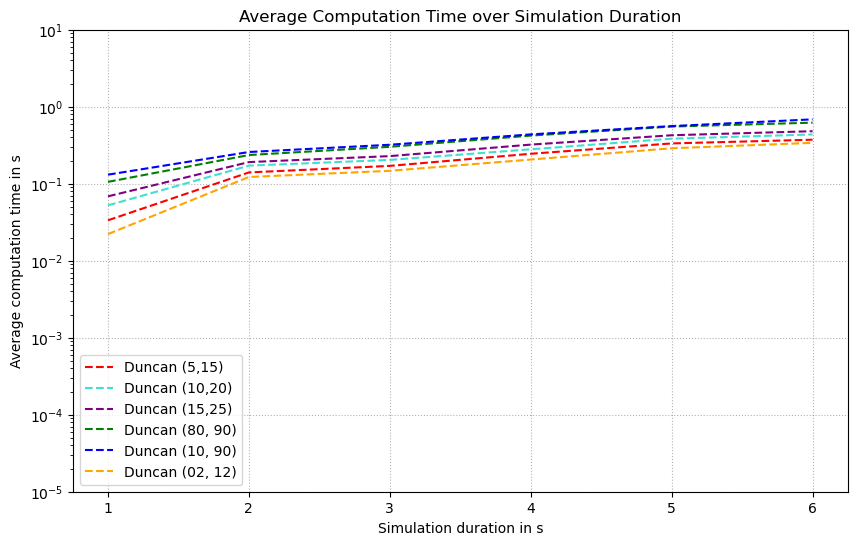

In [8]:
t_range = np.arange(1,7)

comp_times_ssa = [0.007130528450012200,0.05120237421989441,0.493678466796875,0.7586890497207641,1.9541869776248932,8.101672329425812]
comp_times_duncan_5_15 = [0.033525423049926756,0.14022101426124572,0.17047720861434937,0.2449316952228546,0.3337243013381958,0.3728805594444275]
comp_times_cle = [0.004609558820724487, 0.006813064098358155, 0.010476536750793457, 0.014438545227050781, 0.017601205110549925, 0.020727986097335817]
comp_times_duncan_10_20 = [0.05237936520576477,0.1717735891342163,0.2038367156982422,0.2798634684085846,0.38439693093299865,0.43640247082710265]
comp_times_duncan_15_25 = [0.06858846306800842,0.1909893867969513,0.2282994611263275,0.3220999958515167,0.42602009773254396,0.480909081697464]
comp_times_alfonsi = [0.295046945810318,0.34656325268745425,0.5315968811511993,0.49059037113189696, 0.5300318374633789, 0.5743008558750152]

fig,ax = plt.subplots(figsize=(10,6))
#ax.plot(t_range,comp_times_ssa,color="blue", ls="--",label="SSA")
ax.plot(t_range,comp_times_duncan_5_15,color="red", ls="--",label="Duncan (5,15)")
ax.plot(t_range,comp_times_duncan_10_20,color="turquoise", ls="--",label="Duncan (10,20)")
ax.plot(t_range,comp_times_duncan_15_25,color="purple", ls="--",label="Duncan (15,25)")
ax.plot(t_range,comp_times_duncan_80_90,color="green", ls="--",label="Duncan (80, 90)")
ax.plot(t_range,comp_times_duncan_10_90,color="blue", ls="--",label="Duncan (10, 90)")
ax.plot(t_range,comp_times_duncan_02_12,color="orange", ls="--",label="Duncan (02, 12)")
#ax.plot(t_range,comp_times_alfonsi,color="orange", ls="--",label="Alfonsi")
#ax.plot(t_range,comp_times_cle,color="green", ls="--",label="CLE")

ax.set_yscale('log')
ax.set_ylim(10**(-5), 10**1)
ax.set_xlabel("Simulation duration in s")
ax.set_ylabel("Average computation time in s")
ax.legend()
ax.set_title("Average Computation Time over Simulation Duration")
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
path = os.path.join("/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit",f"result_lotka_volterra_comparison_computation_time_blendings.png")
plt.savefig(path)
plt.show()

### Weak order of convergence

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

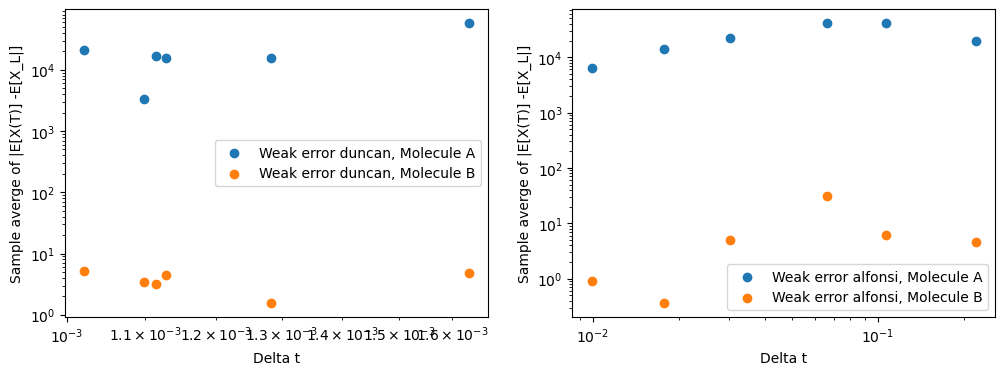


Gesamtdauer: 455.04 Sekunden.


In [ ]:
# Weak order of convergence: |E[X_n] - E[X(t)]| <= C* Delta_t^gamma
import time

def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[ti].append(current_result[1][idx].copy())
    for _,ti in enumerate(time_points):
        data[ti] = np.array(data[ti])
    return data

M = 10**2
t0 = 0
tf = 5
k1 = 2.0
k2 = 0.002
k3 = 2.0
A0 = 50
B0 = 60
S = np.array([[1,-1,0],[0,1,-1]])
S_ed = np.array([[1,1,0],[0,1,1]],dtype=int)
c = np.array([k1,k2,k3]) 
x0 = np.array([A0,B0])
Delta_t = 10**(-3)
delta_t = 10**(-2)

alfonsi_lambdas = [640,320,160,80,40,20]
duncan_I2s = [640,320,160,80,40,20]

path_ssa= "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit/result_lotka_volterra_ssa.csv"
time_points = [5]
data_ssa = {5:[]}
data_ssa = fill_time_dict_gen(data_ssa,path_ssa,3,1000,time_points)
data_ssa = data_ssa[5]
data_ssa = np.mean(data_ssa, axis=0)

alfonsi_errors, alfonsi_dts = [], []
duncan_errors, duncan_dts = [], []
start = time.time()

for threshold in alfonsi_lambdas:
    total_N_alfonsi, total_N_duncan = 0, 0
    mean_alfonsi, mean_duncan = np.zeros((M,2)), np.zeros((M,2))
    for i in range(M):
        boundaries = np.array([threshold*0.5,threshold,threshold*0.5,threshold])
        _,X_alfonsi,N_alfonsi = stochastinetics.hybrid(S,S_ed,c,t0,x0,tf,threshold)
        _,X_duncan,N_duncan = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t0,x0,tf,delta_t,Delta_t,boundaries)
        total_N_alfonsi += N_alfonsi
        total_N_duncan += N_duncan
        mean_alfonsi[i,:] = X_alfonsi[-1,:]
        mean_duncan[i,:] = X_duncan[-1,:]
    mean_duncan = np.mean(mean_duncan, axis=0)
    mean_alfonsi = np.mean(mean_alfonsi,axis=0)
    alfonsi_errors.append(abs(mean_alfonsi-data_ssa))
    alfonsi_dts.append((tf*M)/total_N_alfonsi)
    duncan_errors.append(abs(mean_duncan-data_ssa))
    duncan_dts.append((tf*M)/total_N_duncan)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].scatter(duncan_dts,np.array(duncan_errors)[:,0], label="Weak error duncan, Molecule A")
axes[0].scatter(duncan_dts,np.array(duncan_errors)[:,1], label="Weak error duncan, Molecule B")
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_xlabel("Delta t")
axes[0].set_ylabel("Sample averge of |E[X(T)] -E[X_L|]")
axes[0].legend()
axes[1].scatter(alfonsi_dts,np.array(alfonsi_errors)[:,0],label="Weak error alfonsi, Molecule A")
axes[1].scatter(alfonsi_dts,np.array(alfonsi_errors)[:,1],label="Weak error alfonsi, Molecule B")
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_xlabel("Delta t")
axes[1].set_ylabel("Sample averge of |E[X(T)] -E[X_L|]")
axes[1].legend()
plt.show()

end = time.time()
print(f"\nGesamtdauer: {end - start:.2f} Sekunden.")


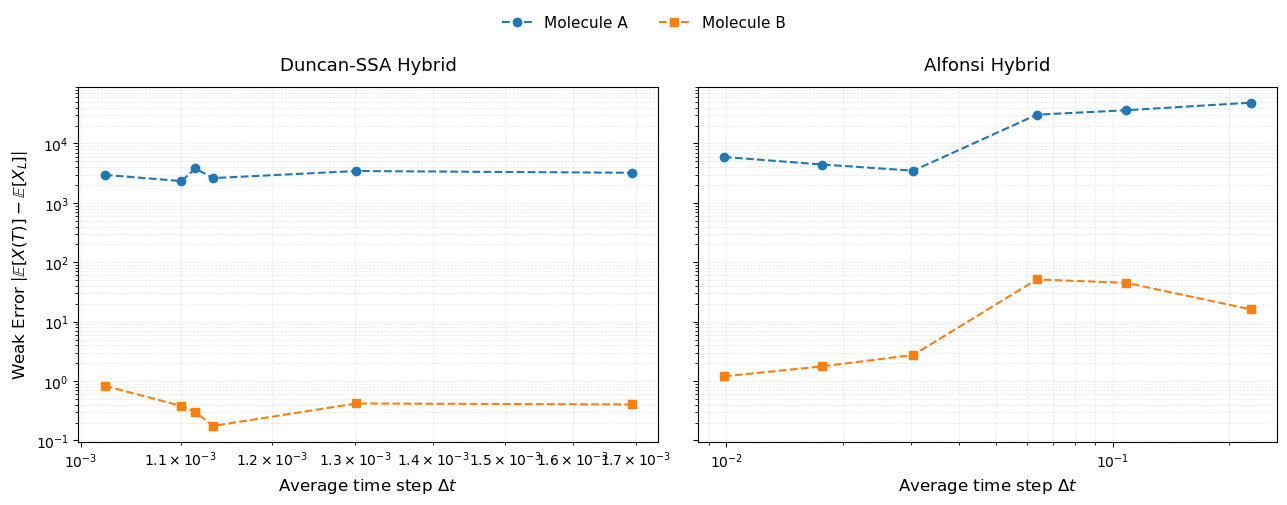

In [5]:
alfonsi_errors= [np.array([5.93417577e+03, 1.20254947e+00]), np.array([4.42105232e+03, 1.76839458e+00]), np.array([3.48248841e+03, 2.75261612e+00]), np.array([30539.33040098,    51.51917992]), np.array([36253.82189595,    45.04659223]), np.array([4.86202829e+04, 1.61330423e+01])]
alfonsi_dts= [0.009866287727549647, 0.01770080993596024, 0.03047665488236011, 0.06362476657663763, 0.10844944835019107, 0.22732966302014732]
duncan_errors= [np.array([2.96047605e+03, 8.32924549e-01]), np.array([2.32611549e+03, 3.81176091e-01]), np.array([3.79629999e+03, 3.02904148e-01]), np.array([2.61110272e+03, 1.75685442e-01]), np.array([3.43709868e+03, 4.19975888e-01]), np.array([3.21449470e+03, 4.04147032e-01])]
duncan_dts= [0.0010232363802674153, 0.0011009793607766678, 0.001115750107483555, 0.0011346964269035868, 0.00130102594143987, 0.001692687568376749]

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), sharey=True)

duncan_err = np.array(duncan_errors)
alfonsi_err = np.array(alfonsi_errors)

color_A, color_B = '#1f77b4', '#ff7f0e'
marker_A, marker_B = 'o', 's'

axes[0].plot(duncan_dts, duncan_err[:, 0], label="Molecule A", color=color_A, marker=marker_A, linestyle='--', linewidth=1.5, markersize=6)
axes[0].plot(duncan_dts, duncan_err[:, 1], label="Molecule B", color=color_B, marker=marker_B, linestyle='--', linewidth=1.5, markersize=6)
axes[0].set_title("Duncan-SSA Hybrid", pad=12)

axes[1].plot(alfonsi_dts, alfonsi_err[:, 0], label="Molecule A", color=color_A, marker=marker_A, linestyle='--', linewidth=1.5, markersize=6)
axes[1].plot(alfonsi_dts, alfonsi_err[:, 1], label="Molecule B", color=color_B, marker=marker_B, linestyle='--', linewidth=1.5, markersize=6)
axes[1].set_title("Alfonsi Hybrid", pad=12)

for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"Average time step $\Delta t$")
    ax.grid(True, which="both", ls="--", lw=0.5)

axes[0].set_ylabel(r"Weak Error $\left| \mathbb{E}[X(T)] - \mathbb{E}[X_L] \right|$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False)

plt.tight_layout()
fig.subplots_adjust(top=0.85)

#plt.savefig("/work/scheibe5/convergence_plot.png", dpi=300, bbox_inches='tight')
plt.show()